In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_cn7 = pd.read_csv(
    r"C:\dev\KAMP_hoochuteam\data\train\moldset_labeled_cn7.csv"
)
train_rg3 = pd.read_csv(
    r"C:\dev\KAMP_hoochuteam\data\train\moldset_labeled_rg3.csv"
)

# 공통 설정
TARGET = "PassOrFail"
ID_COLS = [c for c in ["Unnamed: 0"] if c in train_cn7.columns]
DATASETS = {"CN7": train_cn7, "RG3": train_rg3}

# Target / ID를 제외한 실제 설명변수 목록
FEATURE_COLS = [c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]
NUMERIC_COLS = train_cn7[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_COLS = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

print("CN7 shape:", train_cn7.shape)
print("RG3 shape:", train_rg3.shape)
print("Target:", TARGET)
print("ID 후보:", ID_COLS)
print("설명변수 개수:", len(FEATURE_COLS))


CN7 shape: (1211, 26)
RG3 shape: (1182, 26)
Target: PassOrFail
ID 후보: ['Unnamed: 0']
설명변수 개수: 24


# #1 데이터 기본 구조 확인

### 1) 데이터 크기 shape

- 데이터셋의 행/열 규모를 확인합니다.


In [4]:
# CN7 데이터의 행(row), 열(column) 개수 확인
train_cn7.shape


(1211, 26)

In [5]:
# RG3 데이터의 행(row), 열(column) 개수 확인
train_rg3.shape


(1182, 26)

### 2) 컬럼명 확인

- 분석에 사용되는 변수명을 확인합니다.


In [6]:
# CN7 컬럼명 확인
train_cn7.columns.tolist()


['Unnamed: 0',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

In [7]:
# RG3 컬럼명 확인
train_rg3.columns.tolist()


['Unnamed: 0',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

### 3) 데이터 타입 확인

- 수치형/문자형 등 실제 저장 타입을 확인합니다.


In [8]:
# CN7 컬럼별 데이터 타입과 결측치 여부 확인
train_cn7.info()


<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1211 non-null   int64  
 1   PassOrFail                1211 non-null   int64  
 2   Injection_Time            1211 non-null   float64
 3   Filling_Time              1211 non-null   float64
 4   Plasticizing_Time         1211 non-null   float64
 5   Cycle_Time                1211 non-null   float64
 6   Clamp_Close_Time          1211 non-null   float64
 7   Cushion_Position          1211 non-null   float64
 8   Plasticizing_Position     1211 non-null   float64
 9   Clamp_Open_Position       1211 non-null   float64
 10  Max_Injection_Speed       1211 non-null   float64
 11  Max_Screw_RPM             1211 non-null   float64
 12  Average_Screw_RPM         1211 non-null   float64
 13  Max_Injection_Pressure    1211 non-null   float64
 14  Max_Switch_Over_Pre

In [9]:
# RG3 컬럼별 데이터 타입과 결측치 여부 확인
train_rg3.info()


<class 'pandas.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1182 non-null   int64  
 1   PassOrFail                1182 non-null   int64  
 2   Injection_Time            1182 non-null   float64
 3   Filling_Time              1182 non-null   float64
 4   Plasticizing_Time         1182 non-null   float64
 5   Cycle_Time                1182 non-null   float64
 6   Clamp_Close_Time          1182 non-null   float64
 7   Cushion_Position          1182 non-null   float64
 8   Plasticizing_Position     1182 non-null   float64
 9   Clamp_Open_Position       1182 non-null   float64
 10  Max_Injection_Speed       1182 non-null   float64
 11  Max_Screw_RPM             1182 non-null   float64
 12  Average_Screw_RPM         1182 non-null   float64
 13  Max_Injection_Pressure    1182 non-null   float64
 14  Max_Switch_Over_Pre

### 4) 수치형 / 범주형 / 날짜형 변수 구분

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


#### 4-1) 수치형 변수 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [10]:
# Target / ID를 제외한 수치형 설명변수 확인
numeric_cols = train_cn7[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()
numeric_cols


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

#### 4-2) 범주형 변수 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [11]:
# Target / ID를 제외한 범주형 설명변수 확인
categorical_cols = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
categorical_cols


[]

#### 4-3) 날짜형 변수 확인

- 실제 날짜/타임스탬프 변수가 있는지 확인합니다.


In [12]:
# 실제 datetime 타입 컬럼 확인
# 현재 데이터의 *_Time 컬럼은 '시간 길이'를 의미하는 수치형 변수이므로 날짜형으로 처리하지 않음
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
date_cols


[]

### 5) 각 컬럼 의미 정리

- 각 공정·센서 변수의 의미를 분석용으로 정리합니다.


In [13]:
# 사출 공정 컬럼의 의미 정리
column_meanings = {
    "Unnamed: 0": "원본 CSV 저장 과정에서 생성된 행 인덱스 성격의 컬럼",
    "PassOrFail": "품질 판정 Target (정상/불량)",
    "Injection_Time": "사출(Injection) 공정 시간",
    "Filling_Time": "금형 내부 충전(Filling) 시간",
    "Plasticizing_Time": "수지를 가소화하는 데 걸린 시간",
    "Cycle_Time": "제품 1개 생산에 소요된 전체 사이클 시간",
    "Clamp_Close_Time": "금형을 닫는 데 걸린 시간",
    "Cushion_Position": "사출 종료 후 스크류의 쿠션 위치",
    "Plasticizing_Position": "가소화 완료 시 스크류 위치",
    "Clamp_Open_Position": "금형 개방 위치",
    "Max_Injection_Speed": "최대 사출 속도",
    "Max_Screw_RPM": "스크류 최대 회전속도(RPM)",
    "Average_Screw_RPM": "스크류 평균 회전속도(RPM)",
    "Max_Injection_Pressure": "최대 사출 압력",
    "Max_Switch_Over_Pressure": "보압 전환 시점의 최대 압력",
    "Max_Back_Pressure": "최대 배압",
    "Average_Back_Pressure": "평균 배압",
    "Barrel_Temperature_1": "배럴 구간 1 온도",
    "Barrel_Temperature_2": "배럴 구간 2 온도",
    "Barrel_Temperature_3": "배럴 구간 3 온도",
    "Barrel_Temperature_4": "배럴 구간 4 온도",
    "Barrel_Temperature_5": "배럴 구간 5 온도",
    "Barrel_Temperature_6": "배럴 구간 6 온도",
    "Hopper_Temperature": "호퍼 온도",
    "Mold_Temperature_3": "금형 온도 센서 3",
    "Mold_Temperature_4": "금형 온도 센서 4",
}

pd.DataFrame({
    "컬럼": train_cn7.columns,
    "의미": [column_meanings.get(c, "추가 확인 필요") for c in train_cn7.columns],
    "dtype": train_cn7.dtypes.astype(str).values
})


,컬럼,의미,dtype
0,Unnamed: 0,원본 CSV 저장 과정에서 생성된 행 인덱스 성격의 컬럼,int64
1,PassOrFail,품질 판정 Target (정상/불량),int64
2,Injection_Time,사출(Injection) 공정 시간,float64
3,Filling_Time,금형 내부 충전(Filling) 시간,float64
4,Plasticizing_Time,수지를 가소화하는 데 걸린 시간,float64
5,Cycle_Time,제품 1개 생산에 소요된 전체 사이클 시간,float64
6,Clamp_Close_Time,금형을 닫는 데 걸린 시간,float64
7,Cushion_Position,사출 종료 후 스크류의 쿠션 위치,float64
8,Plasticizing_Position,가소화 완료 시 스크류 위치,float64
9,Clamp_Open_Position,금형 개방 위치,float64


### 6) Target / ID / 설명변수 구분

- 예측 대상, 식별용 컬럼, 모델 입력 설명변수를 분리합니다.


In [14]:
# Target 변수 확인
# PassOrFail이 모델이 예측해야 할 품질 판정값
target_col = TARGET
target_col


'PassOrFail'

In [15]:
# ID성 변수 확인
# Unnamed: 0은 각 행마다 거의/완전히 고유한 값이면 모델 입력에서 제외하는 것이 일반적
id_summary = pd.DataFrame({
    "nunique": train_cn7.nunique(),
    "unique_ratio": train_cn7.nunique() / len(train_cn7)
}).sort_values("unique_ratio", ascending=False)

id_summary.head()


,nunique,unique_ratio
Unnamed: 0,1211,1.000000
Hopper_Temperature,47,0.038811
Mold_Temperature_4,41,0.033856
Mold_Temperature_3,39,0.032205
Barrel_Temperature_4,36,0.029727


In [16]:
# 설명변수(X) 목록 확인
# Target과 ID 후보를 제외한 공정/센서 변수
feature_cols = [c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]
feature_cols


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

In [17]:
# CN7과 RG3의 Target / ID / 설명변수 구조가 동일한지 확인
print("Target:", TARGET)
print("ID 후보:", ID_COLS)
print("CN7 설명변수 개수:", len([c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]))
print("RG3 설명변수 개수:", len([c for c in train_rg3.columns if c not in [TARGET] + ID_COLS]))
print("컬럼 구조 동일:", train_cn7.columns.tolist() == train_rg3.columns.tolist())


Target: PassOrFail
ID 후보: ['Unnamed: 0']
CN7 설명변수 개수: 24
RG3 설명변수 개수: 24
컬럼 구조 동일: True


---


# #2 데이터 품질 확인

### 1) 결측치 개수 / 비율

- 누락된 값의 개수와 비율을 확인합니다.


In [18]:
# 데이터셋별 결측치 개수와 비율 확인
for name, df in DATASETS.items():
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio(%)": df.isna().mean() * 100
    })
    print(f"\n[{name}]")
    display(missing[missing["missing_count"] > 0] if (missing["missing_count"] > 0).any() else missing.head(0))



[CN7]


,missing_count,missing_ratio(%)



[RG3]


,missing_count,missing_ratio(%)


### 2) 완전 중복 행 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [19]:
# 완전히 동일한 행이 반복되는지 확인
for name, df in DATASETS.items():
    full_dup = df.duplicated().sum()
    feature_dup = df.duplicated(subset=FEATURE_COLS).sum()

    print(f"[{name}] 완전 중복 행:", full_dup)
    print(f"[{name}] 설명변수(X) 기준 중복 행:", feature_dup)


[CN7] 완전 중복 행: 0
[CN7] 설명변수(X) 기준 중복 행: 605
[RG3] 완전 중복 행: 0
[RG3] 설명변수(X) 기준 중복 행: 591


### 3) ID성 컬럼 중복 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [20]:
# ID 후보 컬럼의 중복 여부 확인
# ID라면 일반적으로 한 행을 유일하게 식별해야 하므로 duplicated가 없어야 함
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        print(col, "중복 개수:", df[col].duplicated().sum(),
              "| 고유값:", df[col].nunique(),
              "| 전체 행:", len(df))



[CN7]
Unnamed: 0 중복 개수: 0 | 고유값: 1211 | 전체 행: 1211

[RG3]
Unnamed: 0 중복 개수: 0 | 고유값: 1182 | 전체 행: 1182


### 4) 컬럼별 고유값 개수 확인

- 변수별 값의 다양성과 ID성 여부를 확인합니다.


In [21]:
# 컬럼별 고유값 개수와 비율 확인
for name, df in DATASETS.items():
    unique_summary = pd.DataFrame({
        "nunique": df.nunique(dropna=False),
        "unique_ratio(%)": df.nunique(dropna=False) / len(df) * 100
    }).sort_values("nunique")

    print(f"\n[{name}]")
    display(unique_summary)



[CN7]


,nunique,unique_ratio(%)
Clamp_Open_Position,1,0.082576
PassOrFail,2,0.165153
Clamp_Close_Time,3,0.247729
Cushion_Position,5,0.412882
Average_Screw_RPM,7,0.578035
Max_Injection_Pressure,8,0.660611
Max_Screw_RPM,8,0.660611
Cycle_Time,13,1.073493
Plasticizing_Position,13,1.073493
Barrel_Temperature_6,13,1.073493



[RG3]


,nunique,unique_ratio(%)
Clamp_Open_Position,1,0.084602
PassOrFail,2,0.169205
Filling_Time,2,0.169205
Injection_Time,3,0.253807
Clamp_Close_Time,3,0.253807
Max_Screw_RPM,4,0.338409
Average_Screw_RPM,4,0.338409
Cushion_Position,7,0.592217
Max_Injection_Speed,7,0.592217
Plasticizing_Position,8,0.676819


### 5) 상수 컬럼 확인

- 정보량이 없는 상수 또는 거의-상수 변수를 확인합니다.


In [22]:
# 모든 행에서 값이 동일한 상수 컬럼 확인
for name, df in DATASETS.items():
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}] 상수 컬럼:", constant_cols)


[CN7] 상수 컬럼: ['Clamp_Open_Position']
[RG3] 상수 컬럼: ['Clamp_Open_Position']


### 6) 거의 한 값만 존재하는 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [23]:
# 특정 값 하나가 99% 이상을 차지하는 거의-상수 컬럼 확인
for name, df in DATASETS.items():
    near_constant = []
    for col in df.columns:
        top_ratio = df[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_ratio >= 0.99:
            near_constant.append((col, round(top_ratio * 100, 2)))

    print(f"[{name}] 거의 한 값만 존재하는 컬럼:", near_constant)


[CN7] 거의 한 값만 존재하는 컬럼: [('Clamp_Open_Position', np.float64(100.0))]
[RG3] 거의 한 값만 존재하는 컬럼: [('Clamp_Open_Position', np.float64(100.0))]


### 7) 잘못된 데이터 타입 확인

- 수치형/문자형 등 실제 저장 타입을 확인합니다.


In [24]:
# 컬럼별 dtype 확인
# 현재 파일 기준 공정 센서값은 수치형이며, object 타입이 예상치 못하게 존재하는지 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] dtype")
    display(df.dtypes.to_frame("dtype"))
    print("object 타입 컬럼:", df.select_dtypes(include="object").columns.tolist())



[CN7] dtype


,dtype
Unnamed: 0,int64
PassOrFail,int64
Injection_Time,float64
Filling_Time,float64
Plasticizing_Time,float64
Cycle_Time,float64
Clamp_Close_Time,float64
Cushion_Position,float64
Plasticizing_Position,float64
Clamp_Open_Position,float64


object 타입 컬럼: []

[RG3] dtype


,dtype
Unnamed: 0,int64
PassOrFail,int64
Injection_Time,float64
Filling_Time,float64
Plasticizing_Time,float64
Cycle_Time,float64
Clamp_Close_Time,float64
Cushion_Position,float64
Plasticizing_Position,float64
Clamp_Open_Position,float64


object 타입 컬럼: []


### 8) 논리적으로 불가능한 값 확인

- 비정상 수치나 데이터 오류 후보를 확인합니다.


In [25]:
# 논리적으로 불가능한 값 후보 확인
# 현재 값들은 음수가 존재하는 것으로 보아 스케일링/표준화된 값일 수 있으므로
# 단순히 '음수'를 오류로 판단하지 않고 NaN/inf 같은 비정상 수치부터 확인
for name, df in DATASETS.items():
    numeric = df.select_dtypes(include=np.number)
    inf_count = np.isinf(numeric).sum().sum()
    nan_count = numeric.isna().sum().sum()

    print(f"[{name}] NaN 개수:", nan_count)
    print(f"[{name}] +inf/-inf 개수:", inf_count)


[CN7] NaN 개수: 0
[CN7] +inf/-inf 개수: 0
[RG3] NaN 개수: 0
[RG3] +inf/-inf 개수: 0


### 9) 범위를 벗어난 값 확인

- 극단값과 비정상 범위 후보를 확인합니다.


In [26]:
# 각 수치형 변수의 최소/최대값과 극단적인 표준점수(|z| > 5) 개수 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS].select_dtypes(include=np.number)
    std = x.std(ddof=0).replace(0, np.nan)
    z = (x - x.mean()) / std

    range_summary = pd.DataFrame({
        "min": x.min(),
        "max": x.max(),
        "|z|>5_count": (z.abs() > 5).sum()
    }).sort_values("|z|>5_count", ascending=False)

    print(f"\n[{name}]")
    display(range_summary)



[CN7]


,min,max,|z|>5_count
Max_Injection_Speed,-1.541785,9.555703,10
Plasticizing_Time,-0.723425,20.038456,6
Average_Screw_RPM,-1.290590,16.086876,6
Cycle_Time,-3.706092,12.562466,4
Max_Switch_Over_Pressure,-10.462947,2.206755,4
Max_Injection_Pressure,-10.861191,1.680236,4
Filling_Time,-7.776799,2.297327,2
Injection_Time,-7.549091,2.080358,2
Average_Back_Pressure,-6.631852,1.753017,2
Cushion_Position,-2.613163,6.943503,2



[RG3]


,min,max,|z|>5_count
Injection_Time,-8.627730,8.569634,16
Cycle_Time,-1.395040,11.761888,8
Max_Switch_Over_Pressure,-13.791078,1.546443,4
Filling_Time,-1.192531,0.838552,0
Clamp_Close_Time,-1.806725,1.033078,0
Cushion_Position,-1.911818,2.867608,0
Plasticizing_Position,-2.537409,2.932550,0
Plasticizing_Time,-2.736231,3.773533,0
Clamp_Open_Position,0.000000,0.000000,0
Max_Injection_Speed,-2.522291,2.187583,0


### 10) 날짜 범위 이상 여부 확인

- 극단값과 비정상 범위 후보를 확인합니다.


In [27]:
# 날짜형 컬럼이 존재하는 경우 범위 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

    print(f"[{name}] 날짜형 컬럼:", date_cols)
    for col in date_cols:
        print(col, ":", df[col].min(), "~", df[col].max())


[CN7] 날짜형 컬럼: []
[RG3] 날짜형 컬럼: []


---


# #3 Target 확인

### 1) Target 종류 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [28]:
# Target에 어떤 클래스 값이 존재하는지 확인
for name, df in DATASETS.items():
    print(f"[{name}] Target 종류:", sorted(df[TARGET].dropna().unique().tolist()))


[CN7] Target 종류: [0, 1]
[RG3] Target 종류: [0, 1]


### 2) 분류 / 회귀 문제 구분

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [29]:
# 고유값 개수를 기준으로 분류/회귀 문제를 확인
# PassOrFail은 소수의 이산 클래스이므로 분류 문제
for name, df in DATASETS.items():
    n_class = df[TARGET].nunique()
    problem_type = "분류(Classification)" if n_class <= 20 else "회귀 가능성 확인 필요"
    print(f"[{name}] {problem_type} | 클래스 수: {n_class}")


[CN7] 분류(Classification) | 클래스 수: 2
[RG3] 분류(Classification) | 클래스 수: 2


### 3) 분류 문제일 경우 Target 클래스 개수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [30]:
# 분류 문제의 Target 클래스 개수 확인
for name, df in DATASETS.items():
    print(f"[{name}] 클래스 개수:", df[TARGET].nunique())


[CN7] 클래스 개수: 2
[RG3] 클래스 개수: 2


### 4) 클래스별 데이터 수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [31]:
# 클래스별 데이터 수 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df[TARGET].value_counts().sort_index().to_frame("count"))



[CN7]


,count
PassOrFail,
0,1194
1,17



[RG3]


,count
PassOrFail,
0,1157
1,25


### 5) 클래스별 비율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [32]:
# 클래스별 비율 확인
for name, df in DATASETS.items():
    ratio = df[TARGET].value_counts(normalize=True).sort_index() * 100
    print(f"\n[{name}]")
    display(ratio.to_frame("ratio(%)"))



[CN7]


,ratio(%)
PassOrFail,
0,98.596201
1,1.403799



[RG3]


,ratio(%)
PassOrFail,
0,97.884941
1,2.115059


### 6) 클래스 불균형 여부 확인

- Target 또는 데이터 구성의 편향 여부를 확인합니다.


In [33]:
# 다수 클래스 / 소수 클래스 비율로 불균형 정도 확인
for name, df in DATASETS.items():
    counts = df[TARGET].value_counts()
    imbalance_ratio = counts.max() / counts.min()

    print(f"[{name}] 다수:소수 클래스 비율 = {imbalance_ratio:.2f}:1")


[CN7] 다수:소수 클래스 비율 = 70.24:1
[RG3] 다수:소수 클래스 비율 = 46.28:1


### 7) 회귀 문제일 경우 Target 평균 / 중앙값

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [34]:
# 본 데이터는 분류 문제이므로 회귀 Target의 평균/중앙값 해석은 사용하지 않음
print("PassOrFail은 분류 Target이므로 회귀용 평균/중앙값 분석은 생략합니다.")


PassOrFail은 분류 Target이므로 회귀용 평균/중앙값 분석은 생략합니다.


### 8) 최소 / 최대값

- 변수의 값 범위를 확인합니다.


In [35]:
# Target 값의 최소/최대 확인
# 이진 분류라면 일반적으로 0과 1 범위인지 확인 가능
for name, df in DATASETS.items():
    print(f"[{name}] min:", df[TARGET].min(), "| max:", df[TARGET].max())


[CN7] min: 0 | max: 1
[RG3] min: 0 | max: 1


### 9) 표준편차

- 변수의 변동성을 확인합니다.


In [36]:
# 이진 Target의 표준편차 확인
# 모델링 핵심 지표라기보다는 분포 확인용
for name, df in DATASETS.items():
    print(f"[{name}] Target 표준편차:", round(df[TARGET].std(), 6))


[CN7] Target 표준편차: 0.117696
[RG3] Target 표준편차: 0.143947


### 10) Target 분포 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


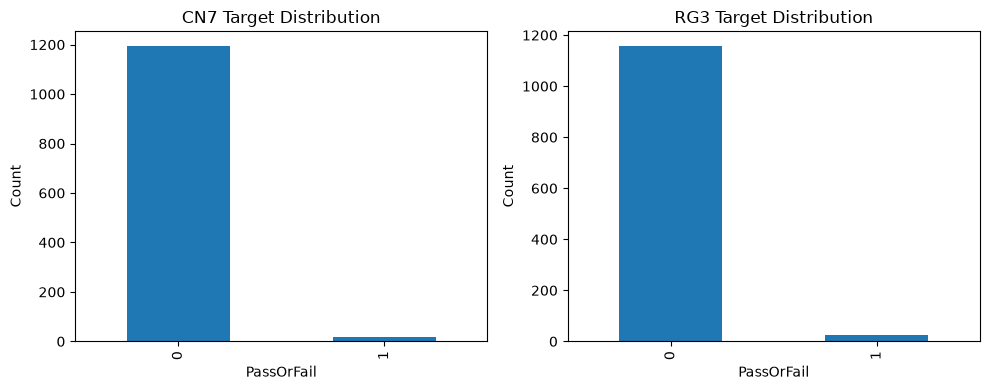

In [37]:
# Target 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, DATASETS.items()):
    df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(f"{name} Target Distribution")
    ax.set_xlabel(TARGET)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


### 11) 왜도 확인

- 분포의 비대칭 정도를 확인합니다.


In [38]:
# Target 왜도 확인
# 불량 클래스가 매우 적으면 큰 양의 왜도가 나타날 수 있음
for name, df in DATASETS.items():
    print(f"[{name}] Target skewness:", round(df[TARGET].skew(), 4))


[CN7] Target skewness: 8.2716
[RG3] Target skewness: 6.6644


### 12) 극단값 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


---


# #4 수치형 변수 기초 통계

### 1) 평균

- 변수의 중심 수준을 비교합니다.


In [39]:
# 수치형 설명변수 평균 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 평균")
    display(df[FEATURE_COLS].mean().sort_values())



[CN7] 평균


Plasticizing_Position      -3.628403e-14
Barrel_Temperature_6       -3.579410e-14
Barrel_Temperature_2       -3.505481e-14
Injection_Time             -2.957172e-14
Barrel_Temperature_1       -1.824176e-14
Max_Switch_Over_Pressure   -1.592414e-14
Clamp_Close_Time           -1.574811e-14
Max_Screw_RPM              -6.688842e-15
Filling_Time               -5.351073e-15
Max_Back_Pressure          -3.755139e-15
Average_Back_Pressure      -3.708200e-15
Hopper_Temperature         -2.675537e-15
Mold_Temperature_3         -8.214367e-16
Mold_Temperature_4         -1.642873e-16
Clamp_Open_Position         0.000000e+00
Max_Injection_Speed         3.238808e-15
Barrel_Temperature_5        5.257195e-15
Plasticizing_Time           6.477615e-15
Barrel_Temperature_3        8.748301e-15
Barrel_Temperature_4        2.114026e-14
Average_Screw_RPM           4.196368e-14
Cycle_Time                  5.069438e-14
Max_Injection_Pressure      1.074909e-13
Cushion_Position            4.630532e-12
dtype: float64


[RG3] 평균


Average_Screw_RPM          -8.432736e-14
Barrel_Temperature_5       -7.989698e-14
Max_Injection_Pressure     -7.252105e-14
Injection_Time             -4.715311e-14
Barrel_Temperature_1       -4.462308e-14
Max_Injection_Speed        -2.755607e-14
Barrel_Temperature_6       -2.174910e-14
Plasticizing_Time          -1.760126e-14
Max_Screw_RPM              -1.206931e-14
Max_Switch_Over_Pressure   -1.161395e-14
Hopper_Temperature         -6.396087e-15
Mold_Temperature_3         -3.847270e-16
Filling_Time               -1.923635e-16
Clamp_Open_Position         0.000000e+00
Mold_Temperature_4          4.809088e-17
Max_Back_Pressure           6.588450e-15
Average_Back_Pressure       8.127359e-15
Barrel_Temperature_3        2.130276e-14
Barrel_Temperature_4        4.068789e-14
Barrel_Temperature_2        4.473654e-14
Clamp_Close_Time            4.972597e-14
Cycle_Time                  5.502649e-14
Plasticizing_Position       1.813267e-13
Cushion_Position            2.788886e-12
dtype: float64

### 2) 중앙값

- 이상치에 덜 민감한 중심값을 확인합니다.


In [40]:
# 수치형 설명변수 중앙값 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 중앙값")
    display(df[FEATURE_COLS].median().sort_values())



[CN7] 중앙값


Clamp_Close_Time           -0.902466
Cushion_Position           -0.711164
Plasticizing_Position      -0.642290
Injection_Time             -0.327014
Hopper_Temperature         -0.168996
Mold_Temperature_4         -0.155625
Average_Screw_RPM          -0.132022
Filling_Time               -0.120461
Barrel_Temperature_3       -0.037728
Plasticizing_Time          -0.036274
Max_Switch_Over_Pressure   -0.010481
Barrel_Temperature_4       -0.006117
Clamp_Open_Position         0.000000
Barrel_Temperature_5        0.008133
Barrel_Temperature_6        0.013158
Max_Injection_Speed         0.015756
Max_Screw_RPM               0.049553
Barrel_Temperature_1        0.056153
Barrel_Temperature_2        0.067358
Mold_Temperature_3          0.093154
Average_Back_Pressure       0.228490
Max_Back_Pressure           0.314806
Cycle_Time                  0.361047
Max_Injection_Pressure      0.635210
dtype: float64


[RG3] 중앙값


Max_Screw_RPM              -0.665752
Average_Screw_RPM          -0.421798
Clamp_Close_Time           -0.386790
Cushion_Position           -0.317055
Plasticizing_Position      -0.192928
Max_Injection_Speed        -0.167384
Max_Injection_Pressure     -0.108802
Max_Back_Pressure          -0.085805
Plasticizing_Time          -0.042538
Barrel_Temperature_5       -0.030765
Injection_Time             -0.029099
Barrel_Temperature_2       -0.011452
Barrel_Temperature_3       -0.002081
Clamp_Open_Position         0.000000
Mold_Temperature_4          0.002053
Barrel_Temperature_4        0.047749
Max_Switch_Over_Pressure    0.075729
Hopper_Temperature          0.081547
Average_Back_Pressure       0.088125
Barrel_Temperature_1        0.096629
Barrel_Temperature_6        0.143005
Mold_Temperature_3          0.173825
Cycle_Time                  0.249511
Filling_Time                0.838552
dtype: float64

### 3) 표준편차

- 변수의 변동성을 확인합니다.


In [41]:
# 수치형 설명변수 표준편차 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 표준편차")
    display(df[FEATURE_COLS].std().sort_values())



[CN7] 표준편차


Clamp_Open_Position         0.000000
Mold_Temperature_4          1.000413
Cycle_Time                  1.000413
Injection_Time              1.000413
Cushion_Position            1.000413
Clamp_Close_Time            1.000413
Plasticizing_Position       1.000413
Filling_Time                1.000413
Barrel_Temperature_1        1.000413
Max_Screw_RPM               1.000413
Average_Screw_RPM           1.000413
Max_Switch_Over_Pressure    1.000413
Average_Back_Pressure       1.000413
Barrel_Temperature_4        1.000413
Barrel_Temperature_2        1.000413
Max_Injection_Speed         1.000413
Barrel_Temperature_5        1.000413
Hopper_Temperature          1.000413
Mold_Temperature_3          1.000413
Barrel_Temperature_3        1.000413
Max_Back_Pressure           1.000413
Max_Injection_Pressure      1.000413
Plasticizing_Time           1.000413
Barrel_Temperature_6        1.000413
dtype: float64


[RG3] 표준편차


Clamp_Open_Position         0.000000
Injection_Time              1.000423
Plasticizing_Time           1.000423
Filling_Time                1.000423
Cycle_Time                  1.000423
Clamp_Close_Time            1.000423
Cushion_Position            1.000423
Plasticizing_Position       1.000423
Max_Injection_Speed         1.000423
Average_Screw_RPM           1.000423
Max_Back_Pressure           1.000423
Max_Switch_Over_Pressure    1.000423
Average_Back_Pressure       1.000423
Barrel_Temperature_1        1.000423
Barrel_Temperature_3        1.000423
Barrel_Temperature_2        1.000423
Barrel_Temperature_6        1.000423
Mold_Temperature_3          1.000423
Barrel_Temperature_4        1.000423
Barrel_Temperature_5        1.000423
Mold_Temperature_4          1.000423
Max_Injection_Pressure      1.000423
Max_Screw_RPM               1.000423
Hopper_Temperature          1.000423
dtype: float64

### 4) 최소값 / 최대값

- 변수의 값 범위를 확인합니다.


In [42]:
# 수치형 설명변수 최소/최대값 확인
for name, df in DATASETS.items():
    summary = pd.DataFrame({
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    })
    print(f"\n[{name}]")
    display(summary)



[CN7]


,min,max
Injection_Time,-7.549091,2.080358
Filling_Time,-7.776799,2.297327
Plasticizing_Time,-0.723425,20.038456
Cycle_Time,-3.706092,12.562466
Clamp_Close_Time,-0.902466,2.859537
Cushion_Position,-2.613163,6.943503
Plasticizing_Position,-2.876962,1.592429
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-1.541785,9.555703
Max_Screw_RPM,-2.486330,3.430752



[RG3]


,min,max
Injection_Time,-8.627730,8.569634
Filling_Time,-1.192531,0.838552
Plasticizing_Time,-2.736231,3.773533
Cycle_Time,-1.395040,11.761888
Clamp_Close_Time,-1.806725,1.033078
Cushion_Position,-1.911818,2.867608
Plasticizing_Position,-2.537409,2.932550
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-2.522291,2.187583
Max_Screw_RPM,-2.008588,2.019970


### 5) 사분위수

- 분포의 중앙 구간과 IQR을 확인합니다.


In [43]:
# 1사분위수(Q1), 중앙값(Q2), 3사분위수(Q3) 확인
for name, df in DATASETS.items():
    q = df[FEATURE_COLS].quantile([0.25, 0.50, 0.75]).T
    q.columns = ["Q1", "Q2", "Q3"]
    print(f"\n[{name}]")
    display(q)



[CN7]


,Q1,Q2,Q3
Injection_Time,-0.728249,-0.327014,0.876653
Filling_Time,-0.523416,-0.120461,0.685468
Plasticizing_Time,-0.379849,-0.036274,0.209135
Cycle_Time,-0.655762,0.361047,0.361047
Clamp_Close_Time,-0.902466,-0.902466,0.978580
Cushion_Position,-0.711164,-0.711164,1.202502
Plasticizing_Position,-0.702654,-0.642290,1.471608
Clamp_Open_Position,0.000000,0.000000,0.000000
Max_Injection_Speed,-0.568321,0.015756,0.405143
Max_Screw_RPM,-0.795730,0.049553,0.894853



[RG3]


,Q1,Q2,Q3
Injection_Time,-0.029099,-0.029099,-0.029099
Filling_Time,-1.192531,0.838552,0.838552
Plasticizing_Time,-0.715956,-0.042538,0.630880
Cycle_Time,-0.298708,0.249511,0.249511
Clamp_Close_Time,-0.386790,-0.386790,1.033078
Cushion_Position,-1.114437,-0.317055,0.480326
Plasticizing_Position,-0.974521,-0.192928,0.588367
Clamp_Open_Position,0.000000,0.000000,0.000000
Max_Injection_Speed,-0.952293,-0.167384,0.617645
Max_Screw_RPM,-0.665752,-0.665752,0.677109


### 6) 왜도

- 분포의 비대칭 정도를 확인합니다.


In [44]:
# 왜도 확인: 절대값이 클수록 한쪽으로 치우친 분포
for name, df in DATASETS.items():
    print(f"\n[{name}] 왜도")
    display(df[FEATURE_COLS].skew().abs().sort_values(ascending=False).to_frame("|skew|"))



[CN7] 왜도


,|skew|
Plasticizing_Time,15.166877
Average_Screw_RPM,8.987925
Max_Injection_Speed,5.271690
Cycle_Time,4.769294
Max_Injection_Pressure,2.879362
Max_Switch_Over_Pressure,2.219345
Cushion_Position,1.015655
Average_Back_Pressure,0.897403
Filling_Time,0.896455
Injection_Time,0.808191



[RG3] 왜도


,|skew|
Cycle_Time,8.386585
Max_Switch_Over_Pressure,8.270600
Injection_Time,2.066939
Hopper_Temperature,0.596808
Plasticizing_Time,0.546343
Clamp_Close_Time,0.439056
Barrel_Temperature_5,0.431009
Filling_Time,0.354429
Barrel_Temperature_2,0.289997
Max_Injection_Pressure,0.275562


### 7) 첨도

- 분포 꼬리와 극단값 경향을 확인합니다.


In [45]:
# 첨도 확인: 값이 클수록 꼬리가 두껍고 극단값이 많을 가능성
for name, df in DATASETS.items():
    print(f"\n[{name}] 첨도")
    display(df[FEATURE_COLS].kurt().sort_values(ascending=False).to_frame("kurtosis"))



[CN7] 첨도


,kurtosis
Plasticizing_Time,281.585669
Average_Screw_RPM,128.886746
Cycle_Time,56.230174
Max_Injection_Speed,46.999535
Max_Injection_Pressure,24.025147
Max_Switch_Over_Pressure,20.100283
Filling_Time,6.703002
Injection_Time,6.098331
Cushion_Position,2.465733
Average_Back_Pressure,2.248759



[RG3] 첨도


,kurtosis
Max_Switch_Over_Pressure,109.775127
Cycle_Time,96.645025
Injection_Time,71.060110
Barrel_Temperature_5,1.644662
Plasticizing_Time,0.457142
Hopper_Temperature,0.102952
Average_Screw_RPM,0.094839
Clamp_Open_Position,0.000000
Barrel_Temperature_3,-0.100903
Barrel_Temperature_1,-0.191491


### 8) 0 또는 특정 값에 데이터가 몰려있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [46]:
# 0이 차지하는 비율과 최빈값 비율 확인
for name, df in DATASETS.items():
    result = []
    for col in FEATURE_COLS:
        zero_ratio = (df[col] == 0).mean() * 100
        top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
        result.append([col, zero_ratio, top_ratio])

    result = pd.DataFrame(result, columns=["column", "zero_ratio(%)", "top_value_ratio(%)"])
    print(f"\n[{name}]")
    display(result.sort_values("top_value_ratio(%)", ascending=False))



[CN7]


,column,zero_ratio(%),top_value_ratio(%)
7,Clamp_Open_Position,100.0,100.000000
10,Average_Screw_RPM,0.0,74.566474
5,Cushion_Position,0.0,62.840628
4,Clamp_Close_Time,0.0,53.674649
3,Cycle_Time,0.0,53.592073
11,Max_Injection_Pressure,0.0,47.646573
9,Max_Screw_RPM,0.0,34.516928
6,Plasticizing_Position,0.0,29.397192
17,Barrel_Temperature_3,0.0,21.800165
20,Barrel_Temperature_6,0.0,20.478943



[RG3]


,column,zero_ratio(%),top_value_ratio(%)
7,Clamp_Open_Position,100.0,100.000000
0,Injection_Time,0.0,98.646362
3,Cycle_Time,0.0,62.774958
1,Filling_Time,0.0,58.714044
10,Average_Screw_RPM,0.0,58.375635
4,Clamp_Close_Time,0.0,42.978003
9,Max_Screw_RPM,0.0,42.808799
6,Plasticizing_Position,0.0,30.287648
5,Cushion_Position,0.0,28.257191
8,Max_Injection_Speed,0.0,27.072758


---


# #5 수치형 변수 분포 분석

### 1) Histogram

- 변수별 전체 분포 형태를 시각적으로 확인합니다.


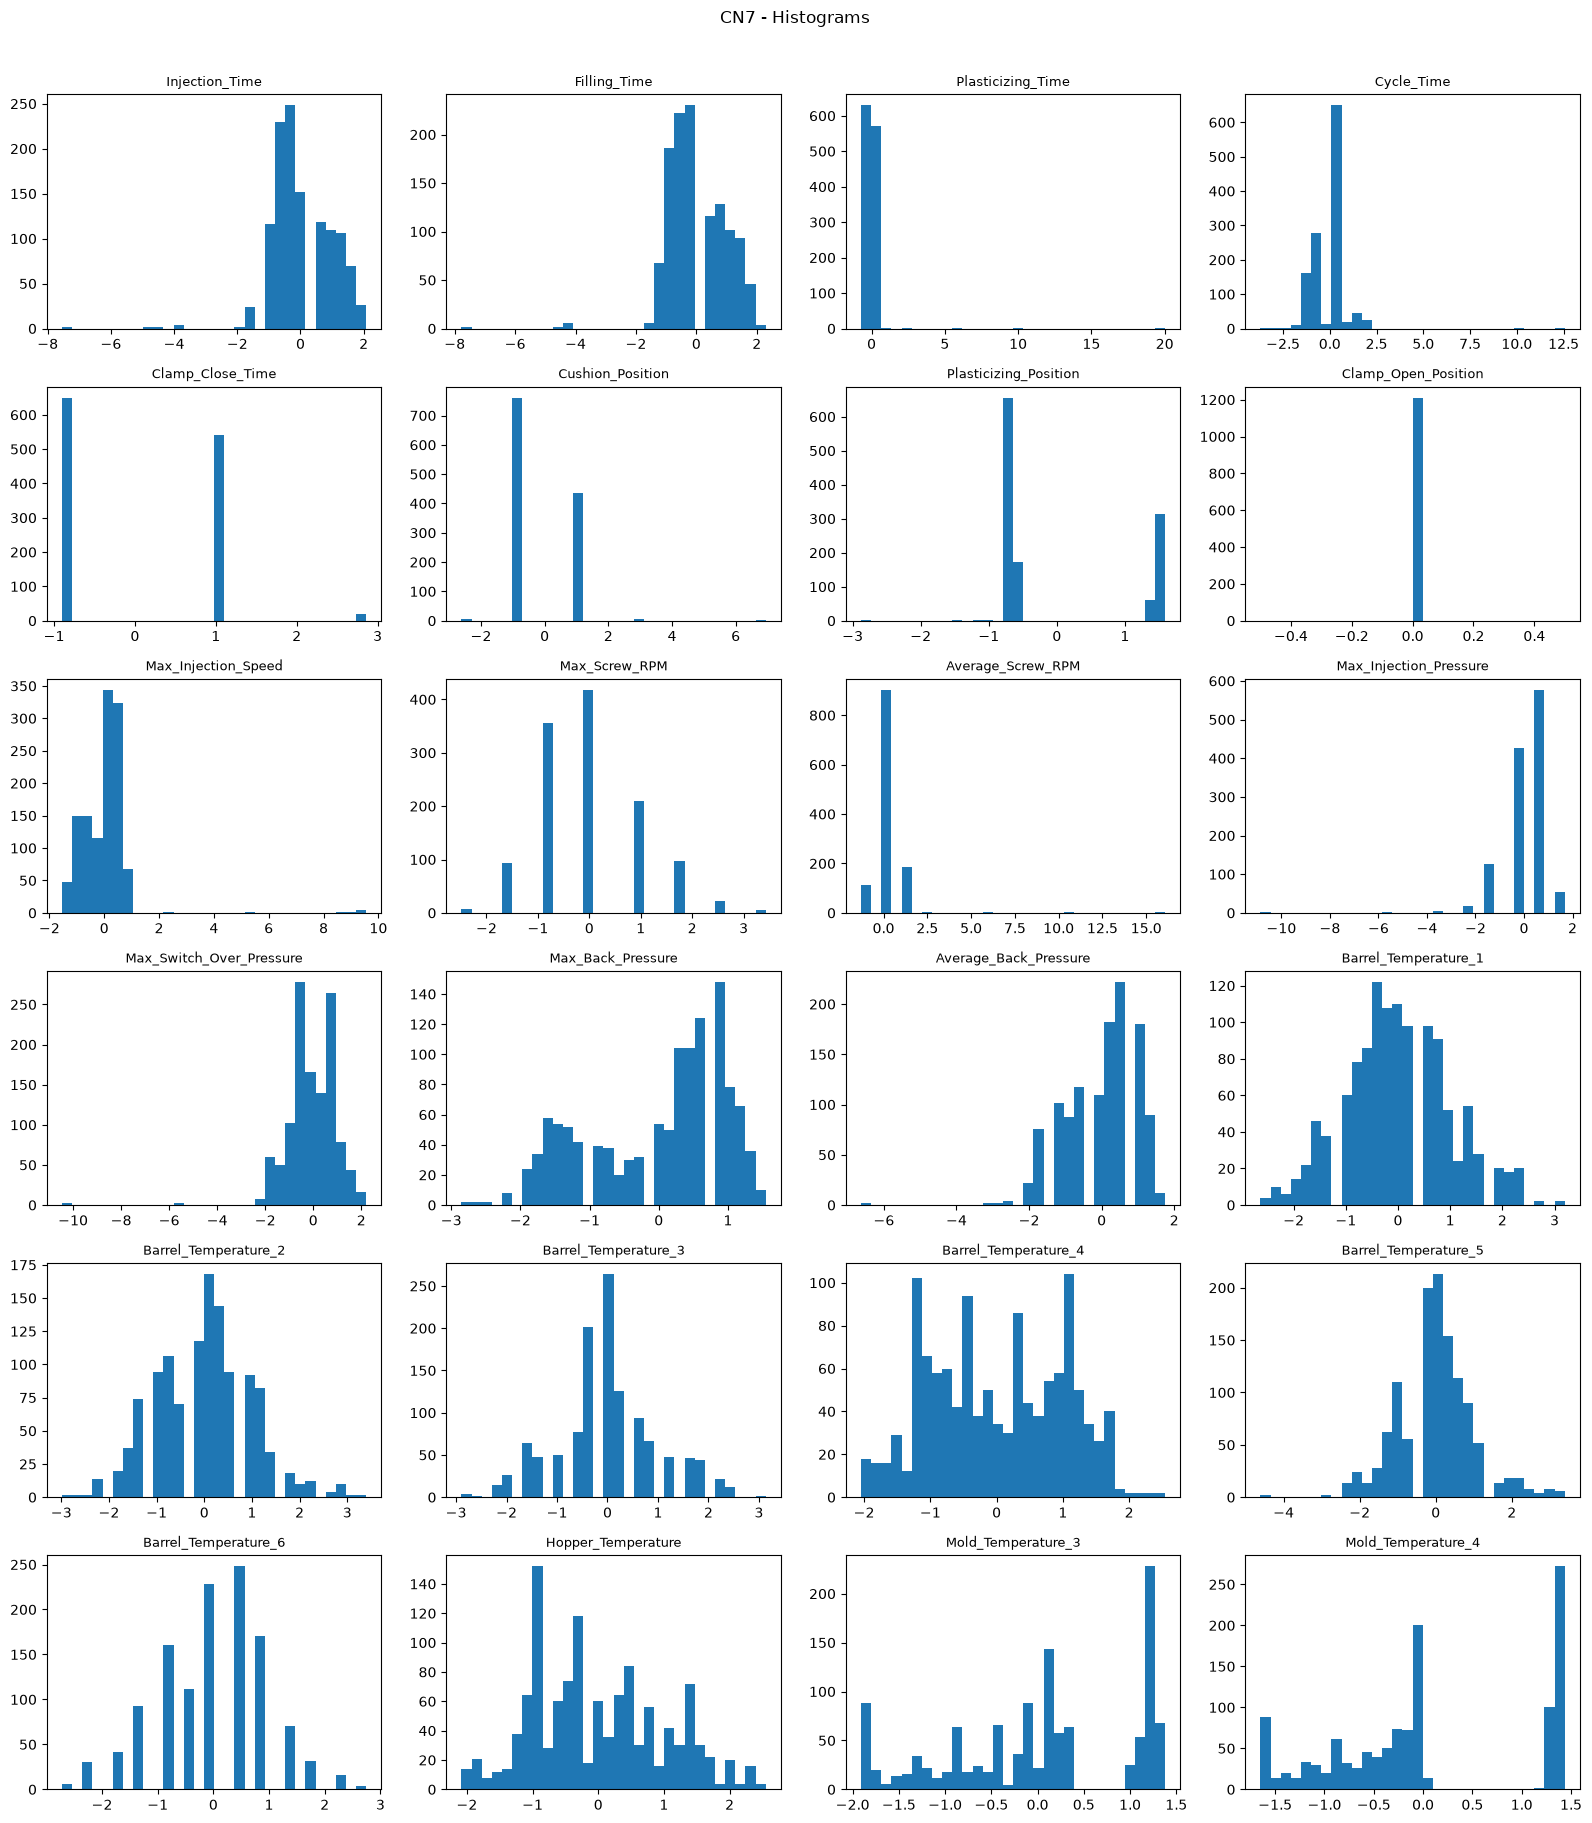

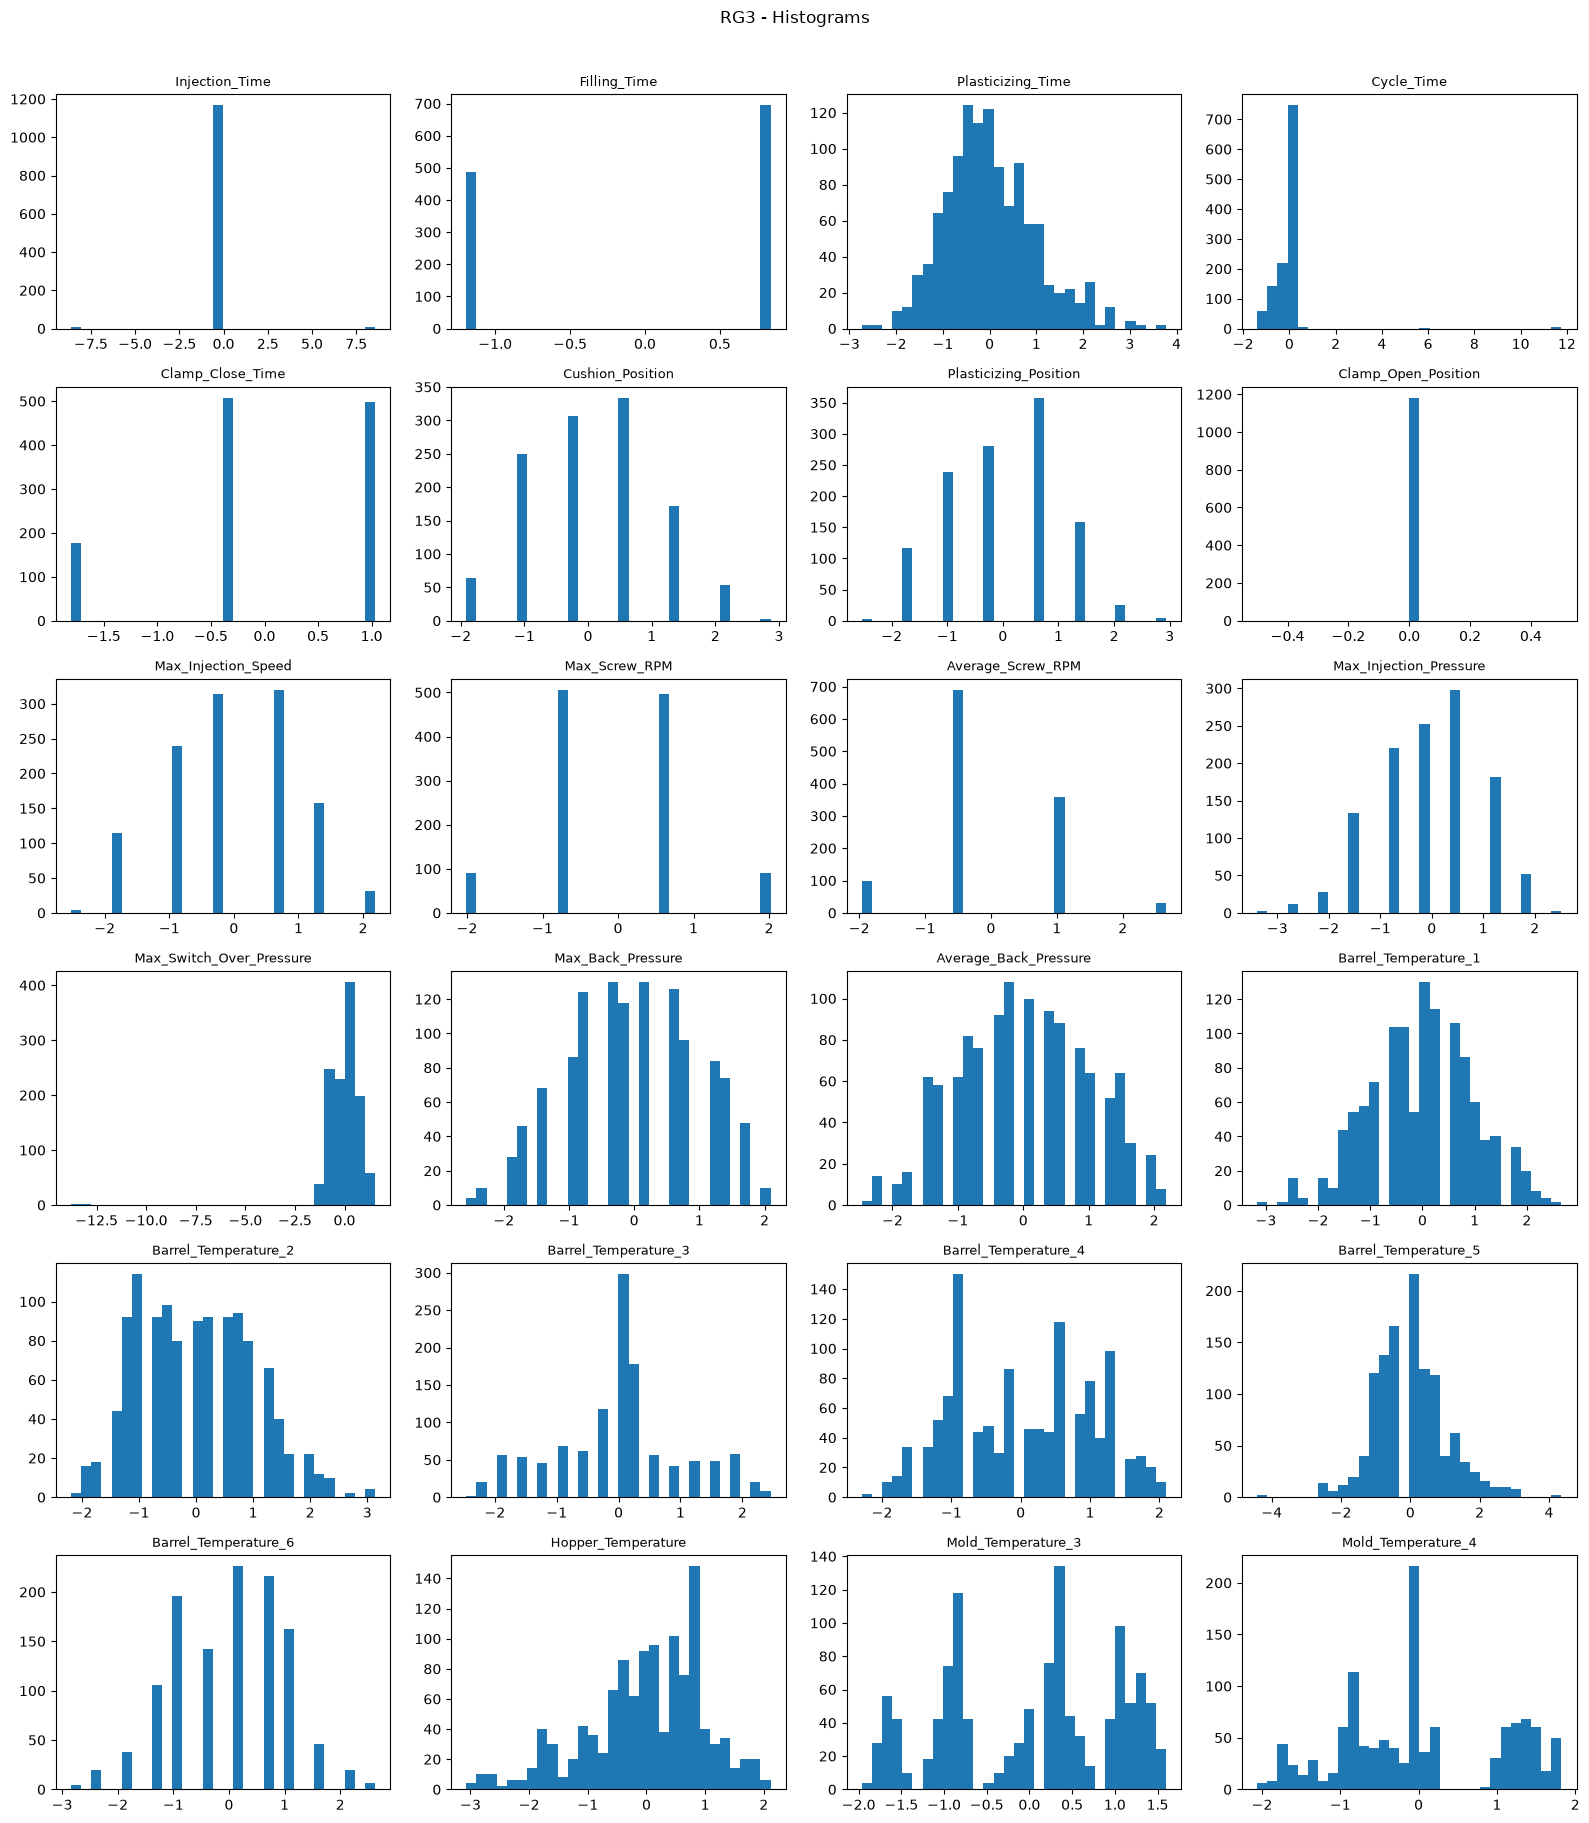

In [47]:
# 각 수치형 변수의 Histogram 확인
for name, df in DATASETS.items():
    cols = FEATURE_COLS
    ncols = 4
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=30)
        ax.set_title(col, fontsize=9)

    for ax in axes[len(cols):]:
        ax.axis("off")

    fig.suptitle(f"{name} - Histograms", y=1.01)
    plt.tight_layout()
    plt.show()


### 2) KDE Plot

- 연속형 변수의 밀도 형태를 확인합니다.


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarn

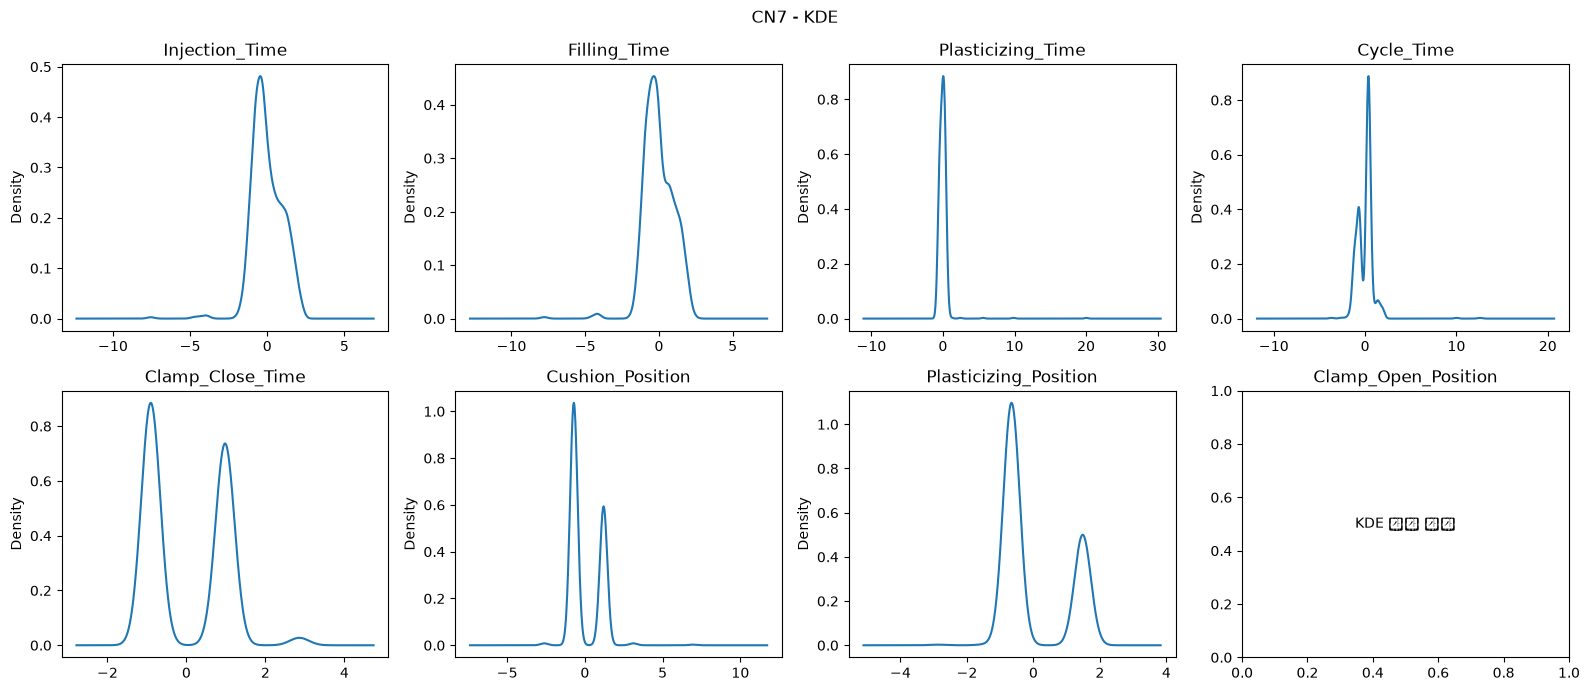

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1392987856.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarn

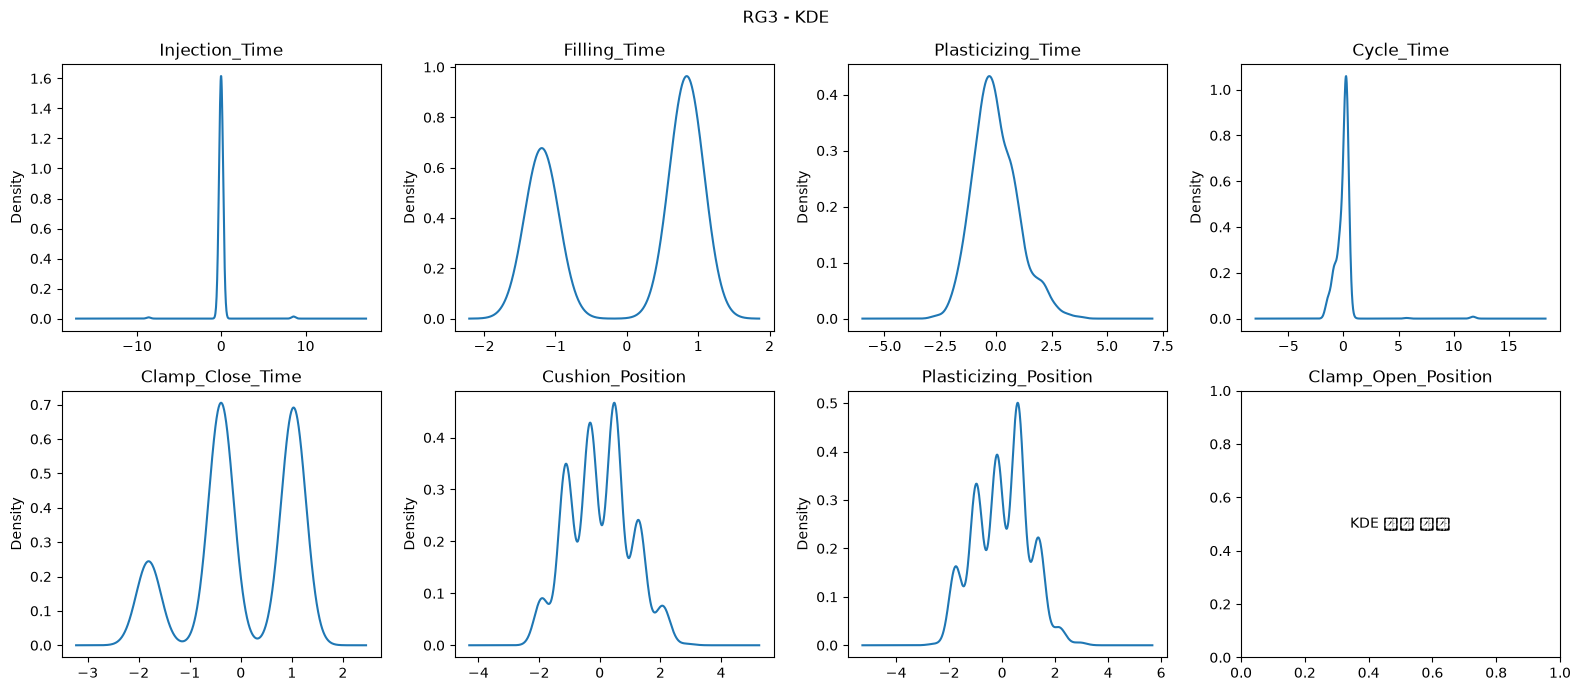

In [48]:
# KDE(밀도) 분포 확인
# 환경에 scipy가 없다면 해당 컬럼은 건너뜀
for name, df in DATASETS.items():
    cols = FEATURE_COLS[:8]  # 너무 많은 그래프를 피하기 위해 앞 8개 우선 확인
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.reshape(-1)

    for ax, col in zip(axes, cols):
        try:
            df[col].dropna().plot(kind="kde", ax=ax)
            ax.set_title(col)
        except Exception:
            ax.text(0.5, 0.5, "KDE 계산 불가", ha="center", va="center")
            ax.set_title(col)

    fig.suptitle(f"{name} - KDE")
    plt.tight_layout()
    plt.show()


### 3) Boxplot

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\4064859760.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


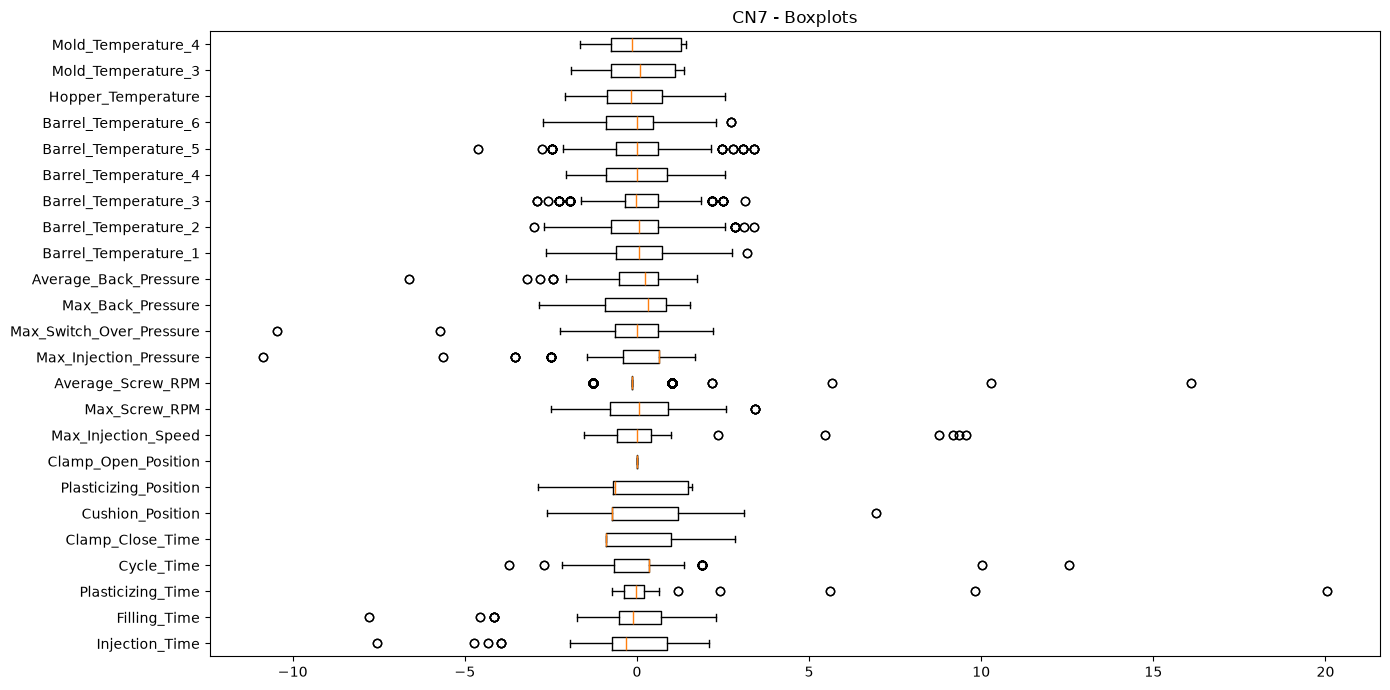

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\4064859760.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


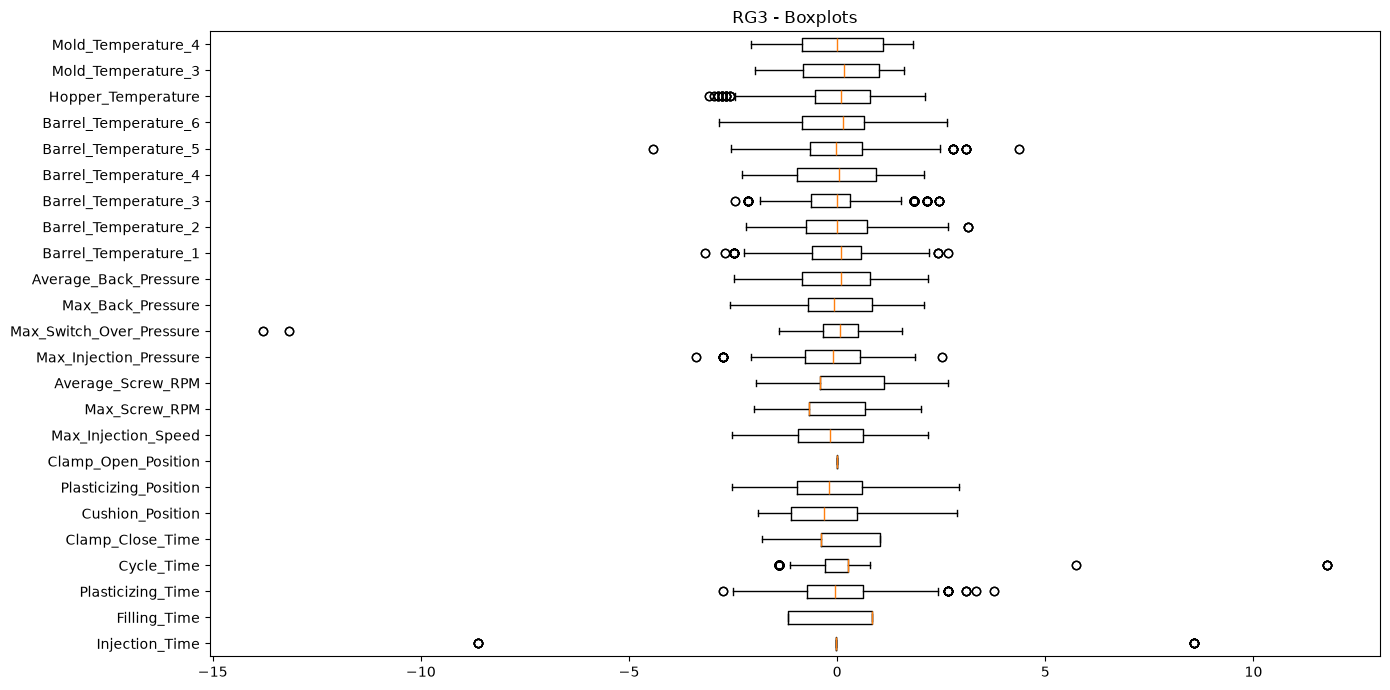

In [50]:
# 각 수치형 변수의 Boxplot 확인
for name, df in DATASETS.items():
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.boxplot(
        [df[c].dropna() for c in FEATURE_COLS],
        tick_labels=FEATURE_COLS,
        vert=False
    )
    
    ax.set_title(f"{name} - Boxplots")
    plt.tight_layout()
    plt.show()


### 4) 분포의 치우침 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [51]:
# 절대 왜도가 큰 변수부터 확인
for name, df in DATASETS.items():
    skewness = df[FEATURE_COLS].skew().sort_values(key=np.abs, ascending=False)
    print(f"\n[{name}] 치우침이 큰 변수")
    display(skewness.to_frame("skewness"))



[CN7] 치우침이 큰 변수


,skewness
Plasticizing_Time,15.166877
Average_Screw_RPM,8.987925
Max_Injection_Speed,5.271690
Cycle_Time,4.769294
Max_Injection_Pressure,-2.879362
Max_Switch_Over_Pressure,-2.219345
Cushion_Position,1.015655
Average_Back_Pressure,-0.897403
Filling_Time,-0.896455
Injection_Time,-0.808191



[RG3] 치우침이 큰 변수


,skewness
Cycle_Time,8.386585
Max_Switch_Over_Pressure,-8.270600
Injection_Time,2.066939
Hopper_Temperature,-0.596808
Plasticizing_Time,0.546343
Clamp_Close_Time,-0.439056
Barrel_Temperature_5,0.431009
Filling_Time,-0.354429
Barrel_Temperature_2,0.289997
Max_Injection_Pressure,-0.275562


### 5) 극단값 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [52]:
# 변수별 상위 1%, 하위 1% 경계값 확인
for name, df in DATASETS.items():
    extreme = pd.DataFrame({
        "1%": df[FEATURE_COLS].quantile(0.01),
        "99%": df[FEATURE_COLS].quantile(0.99),
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    })

    print(f"\n[{name}]")
    display(extreme)



[CN7]


,1%,99%,min,max
Injection_Time,-1.530680,2.080358,-7.549091,2.080358
Filling_Time,-1.732320,1.894372,-7.776799,2.297327
Plasticizing_Time,-0.674351,0.650878,-0.723425,20.038456
Cycle_Time,-1.672571,1.886261,-3.706092,12.562466
Clamp_Close_Time,-0.902466,2.859537,-0.902466,2.859537
Cushion_Position,-0.711164,1.202502,-2.613163,6.943503
Plasticizing_Position,-0.763064,1.592429,-2.876962,1.592429
Clamp_Open_Position,0.000000,0.000000,0.000000,0.000000
Max_Injection_Speed,-1.347095,0.989219,-1.541785,9.555703
Max_Screw_RPM,-1.641030,2.585452,-2.486330,3.430752



[RG3]


,1%,99%,min,max
Injection_Time,-0.029099,-0.029099,-8.627730,8.569634
Filling_Time,-1.192531,0.838552,-1.192531,0.838552
Plasticizing_Time,-2.062813,2.651155,-2.736231,3.773533
Cycle_Time,-1.395040,0.353672,-1.395040,11.761888
Clamp_Close_Time,-1.806725,1.033078,-1.806725,1.033078
Cushion_Position,-1.911818,2.075089,-1.911818,2.867608
Plasticizing_Position,-1.755816,2.151255,-2.537409,2.932550
Clamp_Open_Position,0.000000,0.000000,0.000000,0.000000
Max_Injection_Speed,-1.737322,2.187583,-2.522291,2.187583
Max_Screw_RPM,-2.008588,2.019970,-2.008588,2.019970


### 6) 이상치 후보 탐색

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [53]:
# IQR 기준 이상치 후보 개수 확인
for name, df in DATASETS.items():
    q1 = df[FEATURE_COLS].quantile(0.25)
    q3 = df[FEATURE_COLS].quantile(0.75)
    iqr = q3 - q1

    outlier_mask = (df[FEATURE_COLS] < (q1 - 1.5 * iqr)) | (df[FEATURE_COLS] > (q3 + 1.5 * iqr))
    outlier_count = outlier_mask.sum().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(outlier_count.to_frame("IQR_outlier_count"))



[CN7]


,IQR_outlier_count
Average_Screw_RPM,308
Barrel_Temperature_3,82
Barrel_Temperature_5,44
Cycle_Time,34
Max_Injection_Pressure,28
Barrel_Temperature_2,16
Max_Injection_Speed,12
Injection_Time,10
Plasticizing_Time,10
Filling_Time,10



[RG3]


,IQR_outlier_count
Barrel_Temperature_3,108
Cycle_Time,66
Barrel_Temperature_1,26
Hopper_Temperature,24
Barrel_Temperature_5,22
Plasticizing_Time,22
Injection_Time,16
Max_Injection_Pressure,16
Max_Switch_Over_Pressure,4
Barrel_Temperature_2,4


### 7) 로그 변환이 필요한 변수 확인

- 강하게 치우친 양수 변수의 변환 필요성을 점검합니다.


In [54]:
# 로그 변환 후보 확인
# 일반적으로 양수값만 가지며 왜도가 큰 변수(|skew| > 1)를 후보로 봄
for name, df in DATASETS.items():
    candidates = []
    for col in FEATURE_COLS:
        if (df[col].dropna() > 0).all() and abs(df[col].skew()) > 1:
            candidates.append((col, df[col].skew()))

    print(f"[{name}] 로그 변환 후보:", candidates)
    print("※ 현재 데이터가 이미 표준화된 값이라면 로그 변환은 적용하지 않는 것이 적절합니다.")


[CN7] 로그 변환 후보: []
※ 현재 데이터가 이미 표준화된 값이라면 로그 변환은 적용하지 않는 것이 적절합니다.
[RG3] 로그 변환 후보: []
※ 현재 데이터가 이미 표준화된 값이라면 로그 변환은 적용하지 않는 것이 적절합니다.


### 8) 변수별 스케일 차이 확인

- 변수 간 값의 크기 차이를 확인합니다.


In [55]:
# 변수별 표준편차를 비교하여 스케일 차이 확인
for name, df in DATASETS.items():
    scale = pd.DataFrame({
        "mean": df[FEATURE_COLS].mean(),
        "std": df[FEATURE_COLS].std(),
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    }).sort_values("std", ascending=False)

    print(f"\n[{name}]")
    display(scale)



[CN7]


,mean,std,min,max
Plasticizing_Time,6.477615e-15,1.000413,-0.723425,20.038456
Barrel_Temperature_6,-3.579410e-14,1.000413,-2.719099,2.745415
Max_Back_Pressure,-3.755139e-15,1.000413,-2.851876,1.546295
Max_Injection_Pressure,1.074909e-13,1.000413,-10.861191,1.680236
Clamp_Close_Time,-1.574811e-14,1.000413,-0.902466,2.859537
Injection_Time,-2.957172e-14,1.000413,-7.549091,2.080358
Filling_Time,-5.351073e-15,1.000413,-7.776799,2.297327
Cycle_Time,5.069438e-14,1.000413,-3.706092,12.562466
Barrel_Temperature_1,-1.824176e-14,1.000413,-2.635662,3.196558
Plasticizing_Position,-3.628403e-14,1.000413,-2.876962,1.592429



[RG3]


,mean,std,min,max
Max_Injection_Pressure,-7.252105e-14,1.000423,-3.390701,2.516677
Hopper_Temperature,-6.396087e-15,1.000423,-3.070514,2.115135
Max_Screw_RPM,-1.206931e-14,1.000423,-2.008588,2.019970
Injection_Time,-4.715311e-14,1.000423,-8.627730,8.569634
Clamp_Close_Time,4.972597e-14,1.000423,-1.806725,1.033078
Filling_Time,-1.923635e-16,1.000423,-1.192531,0.838552
Plasticizing_Time,-1.760126e-14,1.000423,-2.736231,3.773533
Cycle_Time,5.502649e-14,1.000423,-1.395040,11.761888
Barrel_Temperature_1,-4.462308e-14,1.000423,-3.166664,2.660669
Plasticizing_Position,1.813267e-13,1.000423,-2.537409,2.932550


---


# #6 범주형 변수 분석

### 1) 카테고리 종류 수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [56]:
# 범주형 변수별 카테고리 종류 수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"[{name}] 범주형 변수:", cat_cols)
    if cat_cols:
        display(df[cat_cols].nunique().to_frame("n_categories"))


[CN7] 범주형 변수: []
[RG3] 범주형 변수: []


### 2) 카테고리별 빈도수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [57]:
# 범주형 변수별 빈도수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")
    for col in cat_cols:
        print(f"\n{col}")
        display(df[col].value_counts(dropna=False))



[CN7]
범주형 설명변수가 없습니다.

[RG3]
범주형 설명변수가 없습니다.


### 3) 카테고리별 비율

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [58]:
# 범주형 변수별 비율 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display((df[col].value_counts(normalize=True, dropna=False) * 100).to_frame("ratio(%)"))



[CN7]
범주형 설명변수가 없습니다.

[RG3]
범주형 설명변수가 없습니다.


### 4) 고유값이 지나치게 많은 변수 확인

- 변수별 값의 다양성과 ID성 여부를 확인합니다.


In [59]:
# 고유값이 지나치게 많은 범주형 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    high_cardinality = [(c, df[c].nunique()) for c in cat_cols if df[c].nunique() > 20]
    print(f"[{name}] 고카디널리티 범주형 변수:", high_cardinality)


[CN7] 고카디널리티 범주형 변수: []
[RG3] 고카디널리티 범주형 변수: []


### 5) 희소한 범주 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [60]:
# 전체의 1% 미만인 희소 범주 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    for col in cat_cols:
        ratio = df[col].value_counts(normalize=True, dropna=False)
        rare = ratio[ratio < 0.01]
        if len(rare):
            print(col)
            display((rare * 100).to_frame("ratio(%)"))
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")



[CN7]
범주형 설명변수가 없습니다.

[RG3]
범주형 설명변수가 없습니다.


### 6) 거의 한 범주만 존재하는 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [61]:
# 한 범주가 95% 이상을 차지하는 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    dominated = []
    for col in cat_cols:
        top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_ratio >= 0.95:
            dominated.append((col, round(top_ratio * 100, 2)))
    print(f"[{name}] 거의 한 범주만 존재:", dominated)


[CN7] 거의 한 범주만 존재: []
[RG3] 거의 한 범주만 존재: []


### 7) 오타 / 표기 방식 차이 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [62]:
# 문자열의 공백/대소문자 차이로 생긴 표기 불일치 후보 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(include="object").columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("문자열 범주형 변수가 없습니다.")
    for col in cat_cols:
        raw_n = df[col].nunique(dropna=False)
        normalized_n = df[col].astype(str).str.strip().str.lower().nunique(dropna=False)
        print(col, "| 원본:", raw_n, "| 정규화 후:", normalized_n)



[CN7]
문자열 범주형 변수가 없습니다.

[RG3]
문자열 범주형 변수가 없습니다.


### 8) 통합 가능한 범주 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [63]:
# 정규화 후 동일해지는 범주가 있는지 확인하여 통합 가능 후보 탐색
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(include="object").columns.tolist()
    print(f"\n[{name}]")
    for col in cat_cols:
        temp = pd.DataFrame({
            "raw": df[col].astype(str),
            "normalized": df[col].astype(str).str.strip().str.lower()
        })
        merged = temp.groupby("normalized")["raw"].nunique()
        print(col, "통합 후보 개수:", (merged > 1).sum())
    if not cat_cols:
        print("통합을 검토할 문자열 범주형 변수가 없습니다.")



[CN7]
통합을 검토할 문자열 범주형 변수가 없습니다.

[RG3]
통합을 검토할 문자열 범주형 변수가 없습니다.


---


# #7 날짜 / 시간 변수 분석

### 1) 데이터 수집 기간 확인

- 실제 날짜형 변수가 있을 경우 관측 기간을 확인합니다.


In [64]:
# 실제 날짜형 컬럼 기준 데이터 수집 기간 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 실제 날짜/타임스탬프 컬럼이 없습니다.")
    for col in date_cols:
        print(f"[{name}] {col} 기간:", df[col].max() - df[col].min())


[CN7] 실제 날짜/타임스탬프 컬럼이 없습니다.
[RG3] 실제 날짜/타임스탬프 컬럼이 없습니다.


### 2) 최초 날짜 / 최근 날짜 확인

- 관측 시작일과 종료일을 확인합니다.


In [65]:
# 최초 날짜 / 최근 날짜 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼 없음")
    for col in date_cols:
        print(f"[{name}] {col}:", df[col].min(), "~", df[col].max())


[CN7] 날짜형 컬럼 없음
[RG3] 날짜형 컬럼 없음


### 3) 연도별 분포

- 시간에 따른 연도 단위 분포를 확인합니다.


In [66]:
# 연도별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 연도별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.year.value_counts().sort_index())


[CN7] 날짜형 컬럼이 없어 연도별 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 연도별 분석을 생략합니다.


### 4) 월별 분포

- 월 단위 계절성/집중 여부를 확인합니다.


In [67]:
# 월별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 월별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.month.value_counts().sort_index())


[CN7] 날짜형 컬럼이 없어 월별 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 월별 분석을 생략합니다.


### 5) 요일별 분포

- 요일별 패턴 여부를 확인합니다.


In [68]:
# 요일별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 요일별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.day_name().value_counts())


[CN7] 날짜형 컬럼이 없어 요일별 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 요일별 분석을 생략합니다.


### 6) 시간대별 분포

- 시간대별 패턴 여부를 확인합니다.


In [69]:
# 시간대별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 시간대별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.hour.value_counts().sort_index())


[CN7] 날짜형 컬럼이 없어 시간대별 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 시간대별 분석을 생략합니다.


### 7) 기간별 데이터 수 변화 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [70]:
# 일 단위 생산/수집 데이터 수 변화 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 기간별 변화 분석을 생략합니다.")
    for col in date_cols:
        daily = df.set_index(col).resample("D").size()
        display(daily.to_frame("count"))


[CN7] 날짜형 컬럼이 없어 기간별 변화 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 기간별 변화 분석을 생략합니다.


### 8) 특정 시점에 데이터가 집중되는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [71]:
# 특정 날짜/시점에 데이터가 과도하게 집중되는지 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 시점 집중도 분석을 생략합니다.")
    for col in date_cols:
        day_ratio = df[col].dt.date.astype(str).value_counts(normalize=True).head(10) * 100
        display(day_ratio.to_frame("ratio(%)"))


[CN7] 날짜형 컬럼이 없어 시점 집중도 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 시점 집중도 분석을 생략합니다.


### 9) 데이터가 없는 기간 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [72]:
# 날짜형 컬럼이 있는 경우 연속 일자에서 비어 있는 날짜 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 누락 기간 분석을 생략합니다.")
    for col in date_cols:
        observed = pd.DatetimeIndex(df[col].dt.normalize().dropna().unique())
        full = pd.date_range(observed.min(), observed.max(), freq="D")
        missing_days = full.difference(observed)
        print(f"[{name}] {col} 누락 날짜 수:", len(missing_days))


[CN7] 날짜형 컬럼이 없어 누락 기간 분석을 생략합니다.
[RG3] 날짜형 컬럼이 없어 누락 기간 분석을 생략합니다.


---


# #8 Target별 수치형 변수 비교

### 1) 클래스별 평균 비교

- 변수의 중심 수준을 비교합니다.


In [73]:
# Target 클래스별 수치형 설명변수 평균 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].mean().T)



[CN7]


PassOrFail,0,1
Injection_Time,0.009360,-0.657436
Filling_Time,0.009477,-0.665645
Plasticizing_Time,0.006107,-0.428935
Cycle_Time,-0.001734,0.121798
Clamp_Close_Time,-0.017084,1.199869
Cushion_Position,0.018081,-1.269889
Plasticizing_Position,-0.021307,1.496483
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-0.038869,2.730002
Max_Screw_RPM,0.003542,-0.248780



[RG3]


PassOrFail,0,1
Injection_Time,0.000629,-0.029099
Filling_Time,-0.000564,0.026119
Plasticizing_Time,-0.003737,0.172956
Cycle_Time,-0.000180,0.008311
Clamp_Close_Time,-0.003914,0.181152
Cushion_Position,0.001337,-0.061893
Plasticizing_Position,0.002145,-0.099268
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,0.000902,-0.041750
Max_Screw_RPM,-0.003024,0.139966


### 2) 클래스별 중앙값 비교

- 이상치에 덜 민감한 중심값을 확인합니다.


In [74]:
# Target 클래스별 수치형 설명변수 중앙값 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].median().T)



[CN7]


PassOrFail,0,1
Injection_Time,-0.327014,0.876653
Filling_Time,-0.120461,1.088442
Plasticizing_Time,-0.036274,-0.428933
Cycle_Time,0.361047,0.361047
Clamp_Close_Time,-0.902466,0.978580
Cushion_Position,-0.711164,-0.711164
Plasticizing_Position,-0.642290,1.471608
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,0.015756,-0.373631
Max_Screw_RPM,0.049553,0.049553



[RG3]


PassOrFail,0,1
Injection_Time,-0.029099,-0.029099
Filling_Time,0.838552,0.838552
Plasticizing_Time,-0.042538,0.181942
Cycle_Time,0.249511,0.249511
Clamp_Close_Time,-0.386790,-0.386790
Cushion_Position,-0.317055,0.480326
Plasticizing_Position,-0.192928,-0.192928
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-0.167384,0.617645
Max_Screw_RPM,-0.665752,0.677109


### 3) 클래스별 표준편차 비교

- 변수의 변동성을 확인합니다.


In [75]:
# Target 클래스별 수치형 설명변수 표준편차 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].std().T)



[CN7]


PassOrFail,0,1
Injection_Time,0.957047,2.631920
Filling_Time,0.955161,2.680328
Plasticizing_Time,1.006129,0.099687
Cycle_Time,0.996138,1.297648
Clamp_Close_Time,0.994509,0.624676
Cushion_Position,0.987404,1.119731
Plasticizing_Position,0.991308,0.048039
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,0.751256,5.057082
Max_Screw_RPM,0.999346,1.075102



[RG3]


PassOrFail,0,1
Injection_Time,1.011174,0.000000
Filling_Time,1.000532,1.015542
Plasticizing_Time,1.003608,0.838605
Cycle_Time,1.008588,0.502416
Clamp_Close_Time,1.002161,0.916533
Cushion_Position,1.001456,0.968963
Plasticizing_Position,1.003040,0.882903
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,0.999670,1.055101
Max_Screw_RPM,1.001668,0.949544


### 4) Boxplot 비교

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\2982416843.py:36: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


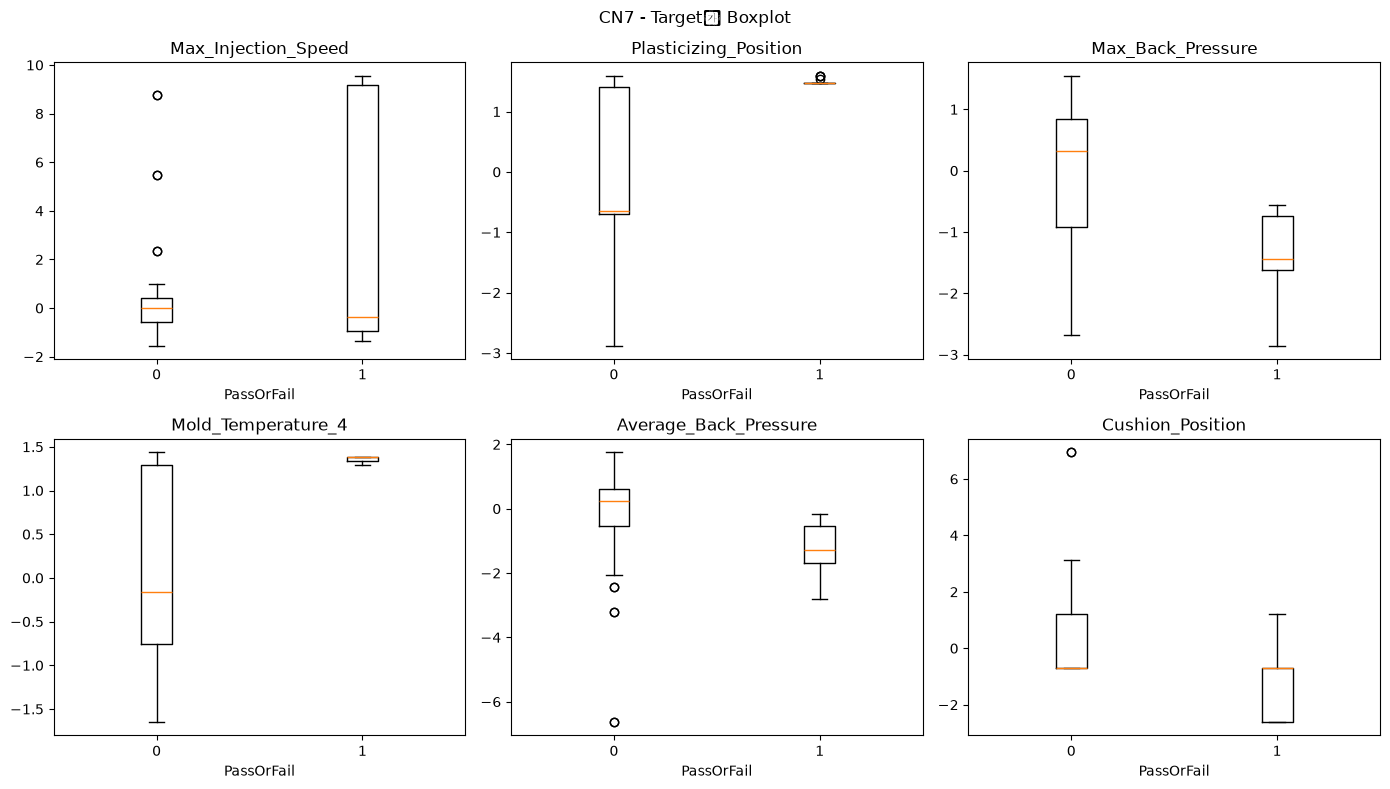

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\2982416843.py:36: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\dev\KAMP_hoochuteam\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


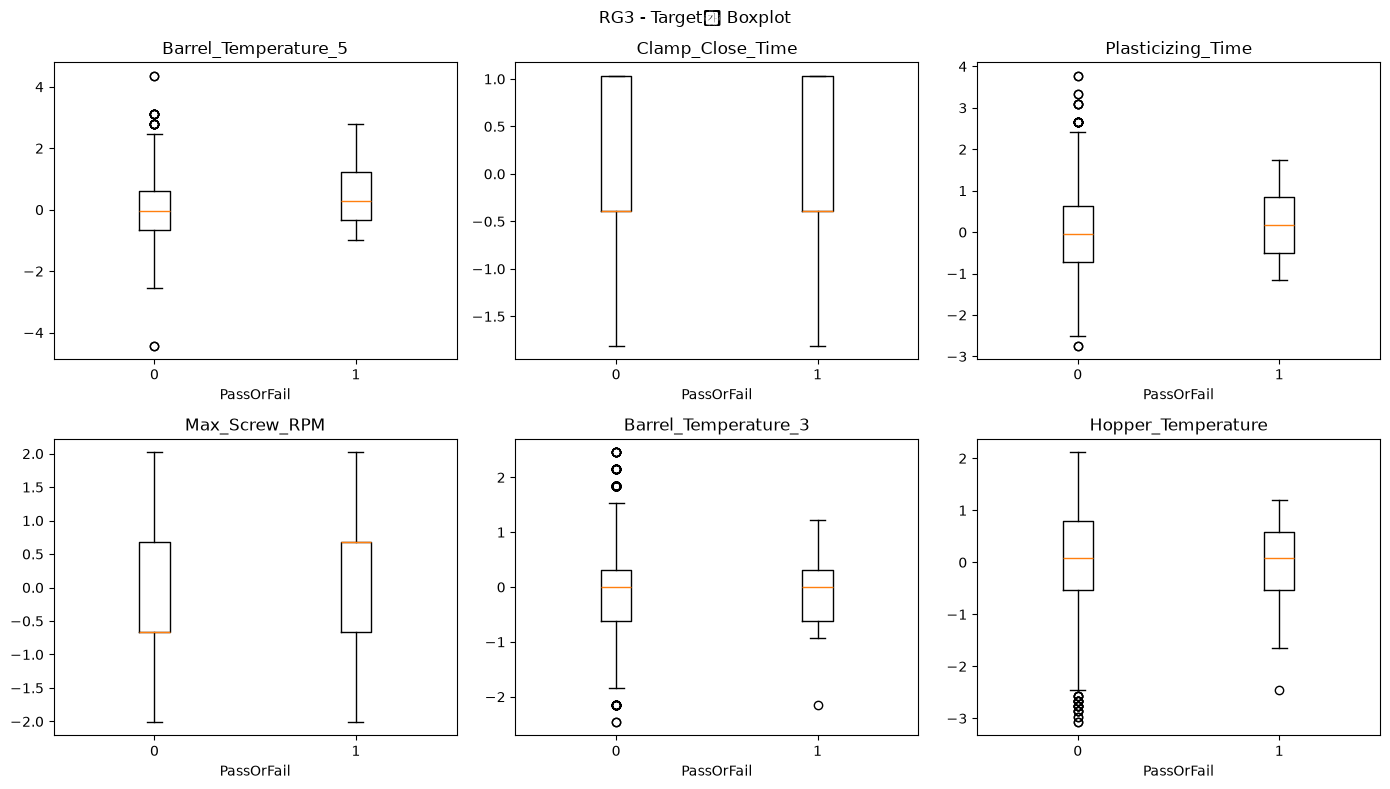

In [77]:
# 클래스 간 평균 차이가 큰 상위 6개 변수의 Boxplot
for name, df in DATASETS.items():

    means = df.groupby(TARGET)[FEATURE_COLS].mean()

    if means.shape[0] == 2:

        top_cols = (
            (means.iloc[1] - means.iloc[0])
            .abs()
            .sort_values(ascending=False)
            .head(6)
            .index
        )

        fig, axes = plt.subplots(2, 3, figsize=(14, 8))

        classes = sorted(df[TARGET].dropna().unique())

        for ax, col in zip(axes.reshape(-1), top_cols):

            data_by_class = [
                df.loc[df[TARGET] == cls, col].dropna()
                for cls in classes
            ]

            ax.boxplot(
                data_by_class,
                tick_labels=classes
            )

            ax.set_title(col)
            ax.set_xlabel(TARGET)

        fig.suptitle(f"{name} - Target별 Boxplot")
        plt.tight_layout()
        plt.show()


### 5) Histogram / KDE 비교

- 변수별 전체 분포 형태를 시각적으로 확인합니다.


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\3646295140.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


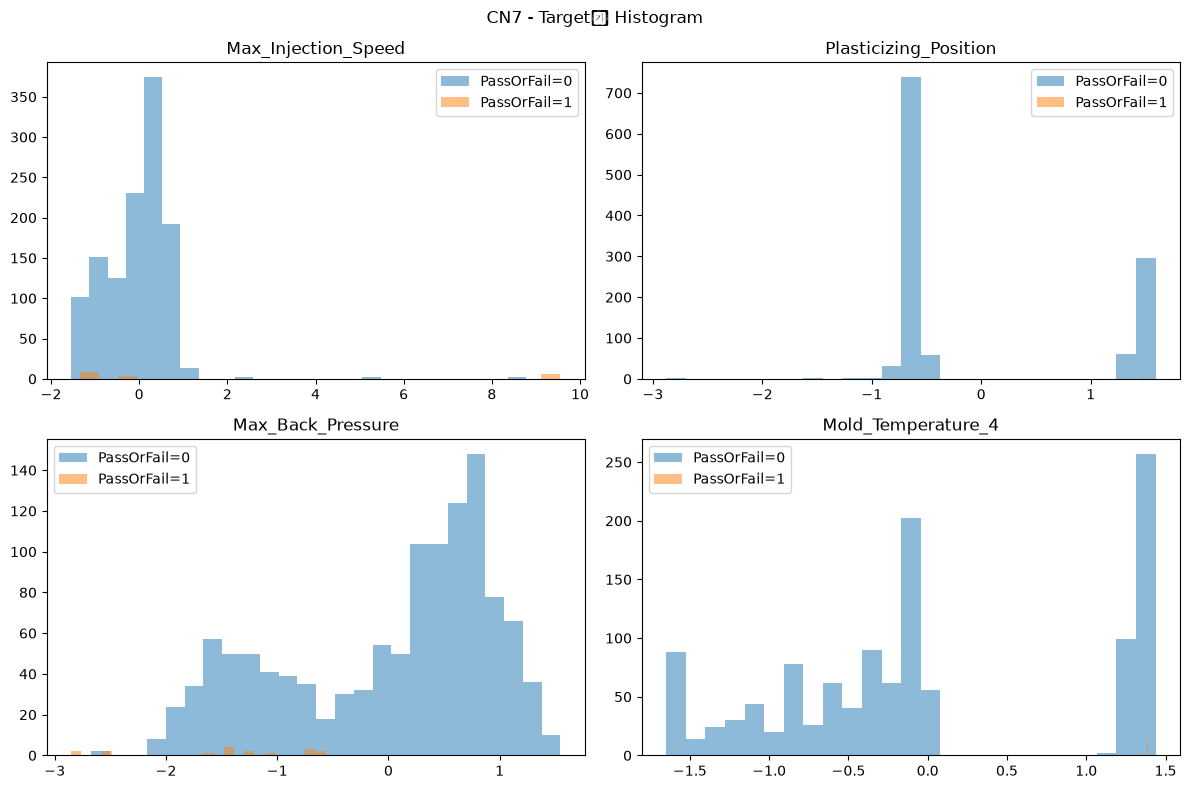

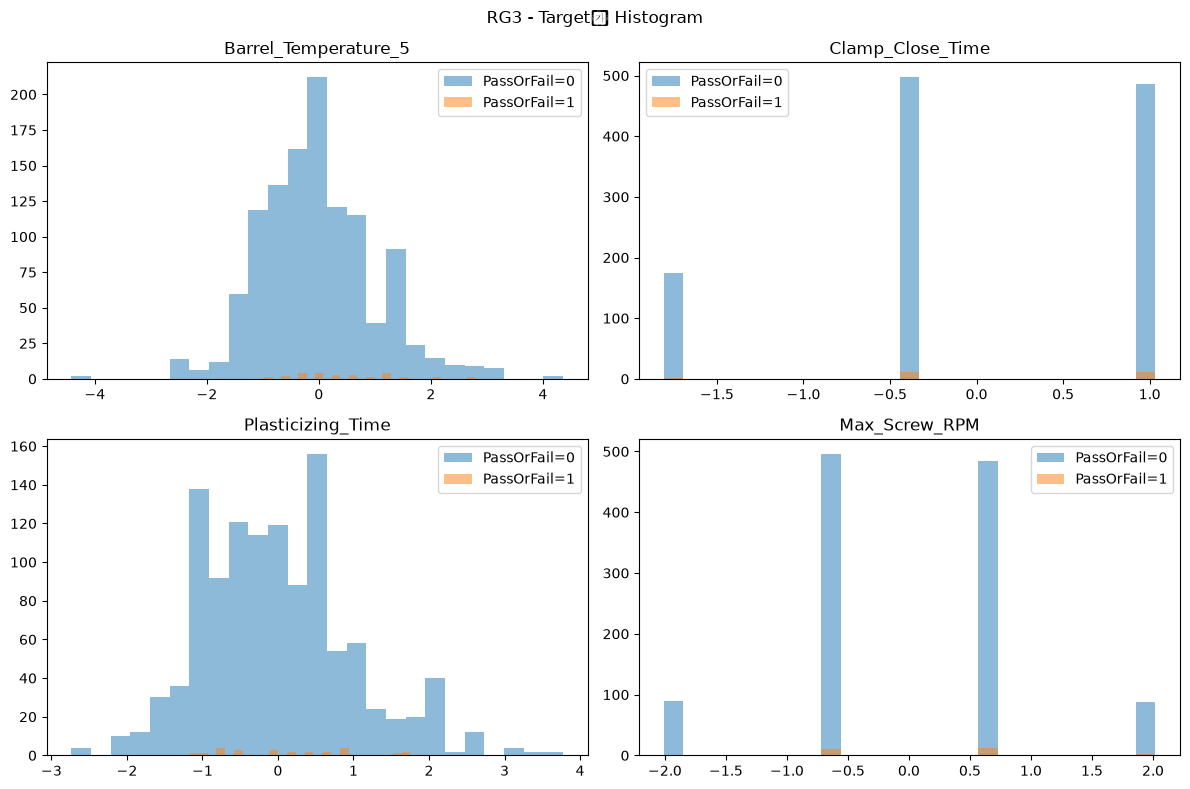

In [78]:
# Target별 분포 차이가 큰 상위 변수의 Histogram 비교
for name, df in DATASETS.items():
    means = df.groupby(TARGET)[FEATURE_COLS].mean()
    if means.shape[0] == 2:
        top_cols = (means.iloc[1] - means.iloc[0]).abs().sort_values(ascending=False).head(4).index

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for ax, col in zip(axes.reshape(-1), top_cols):
            for cls in sorted(df[TARGET].unique()):
                ax.hist(df.loc[df[TARGET] == cls, col].dropna(), bins=25, alpha=0.5, label=f"{TARGET}={cls}")
            ax.set_title(col)
            ax.legend()

        fig.suptitle(f"{name} - Target별 Histogram")
        plt.tight_layout()
        plt.show()


### 6) 두 그룹 간 분포 차이 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [79]:
# 두 Target 그룹 간 표준화 평균 차이(Standardized Mean Difference) 계산
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].dropna().unique())
    if len(classes) == 2:
        c0, c1 = classes
        result = {}

        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col].dropna()
            x1 = df.loc[df[TARGET] == c1, col].dropna()
            pooled_std = np.sqrt((x0.var(ddof=1) + x1.var(ddof=1)) / 2)
            result[col] = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std

        smd = pd.Series(result, name="SMD").sort_values(key=np.abs, ascending=False)
        print(f"\n[{name}]")
        display(smd.to_frame())



[CN7]


,SMD
Plasticizing_Position,2.162762
Mold_Temperature_4,1.970737
Mold_Temperature_3,1.746339
Max_Back_Pressure,-1.691928
Average_Back_Pressure,-1.481356
Clamp_Close_Time,1.465428
Cushion_Position,-1.220081
Max_Switch_Over_Pressure,0.929425
Hopper_Temperature,-0.853325
Max_Injection_Pressure,-0.823745



[RG3]


,SMD
Barrel_Temperature_5,0.474085
Clamp_Close_Time,0.192717
Plasticizing_Time,0.191062
Barrel_Temperature_3,-0.159498
Max_Screw_RPM,0.146513
Hopper_Temperature,-0.141864
Average_Screw_RPM,0.136215
Max_Switch_Over_Pressure,0.123653
Barrel_Temperature_1,-0.114499
Plasticizing_Position,-0.107328


### 7) Target별 차이가 큰 변수 탐색

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [80]:
# Target별 차이가 큰 변수 순위 확인
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].dropna().unique())
    if len(classes) == 2:
        c0, c1 = classes
        ranking = []

        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col]
            x1 = df.loc[df[TARGET] == c1, col]
            pooled_std = np.sqrt((x0.var() + x1.var()) / 2)
            smd = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std
            ranking.append([col, x0.mean(), x1.mean(), smd, abs(smd) if pd.notna(smd) else np.nan])

        ranking = pd.DataFrame(ranking, columns=["column", f"mean_{c0}", f"mean_{c1}", "SMD", "|SMD|"])
        print(f"\n[{name}]")
        display(ranking.sort_values("|SMD|", ascending=False))



[CN7]


,column,mean_0,mean_1,SMD,|SMD|
6,Plasticizing_Position,-0.021307,1.496483,2.162762,2.162762
23,Mold_Temperature_4,-0.019458,1.366613,1.970737,1.970737
22,Mold_Temperature_3,-0.017323,1.216657,1.746339,1.746339
13,Max_Back_Pressure,0.021008,-1.475507,-1.691928,1.691928
14,Average_Back_Pressure,0.019091,-1.340872,-1.481356,1.481356
4,Clamp_Close_Time,-0.017084,1.199869,1.465428,1.465428
5,Cushion_Position,0.018081,-1.269889,-1.220081,1.220081
12,Max_Switch_Over_Pressure,-0.012054,0.846608,0.929425,0.929425
21,Hopper_Temperature,0.009492,-0.666656,-0.853325,0.853325
11,Max_Injection_Pressure,0.017216,-1.209169,-0.823745,0.823745



[RG3]


,column,mean_0,mean_1,SMD,|SMD|
19,Barrel_Temperature_5,-0.009631,0.445713,0.474085,0.474085
4,Clamp_Close_Time,-0.003914,0.181152,0.192717,0.192717
2,Plasticizing_Time,-0.003737,0.172956,0.191062,0.191062
17,Barrel_Temperature_3,0.002967,-0.137298,-0.159498,0.159498
9,Max_Screw_RPM,-0.003024,0.139966,0.146513,0.146513
21,Hopper_Temperature,0.002896,-0.134011,-0.141864,0.141864
10,Average_Screw_RPM,-0.002856,0.132163,0.136215,0.136215
12,Max_Switch_Over_Pressure,-0.002181,0.100936,0.123653,0.123653
15,Barrel_Temperature_1,0.002546,-0.117816,-0.114499,0.114499
6,Plasticizing_Position,0.002145,-0.099268,-0.107328,0.107328


---


# #9 Target별 범주형 변수 비교

### 1) 범주별 Target 개수 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [81]:
# 범주형 변수별 Target 개수 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[col], df[TARGET]))


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 2) 범주별 Target 비율 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [82]:
# 범주별 Target 비율 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[col], df[TARGET], normalize="index") * 100)


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 3) Target별 범주 분포 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [83]:
# Target별 범주 분포 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[TARGET], df[col], normalize="index") * 100)


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 4) 특정 범주에서 Target 발생률이 높은지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [84]:
# 범주별 불량(1) 발생률 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        rate = df.groupby(col)[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False)
        display(rate)


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 5) 희소 범주에서 특이 패턴이 발생하는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [85]:
# 표본이 적은 범주에서 Target 비율이 과도하게 보이는지 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        stat = df.groupby(col)[TARGET].agg(["count", "mean"])
        display(stat[stat["count"] < 10].sort_values("mean", ascending=False))


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


---


# #10 변수 간 상관관계 분석

### 1) 수치형 변수 상관계수 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [86]:
# 수치형 변수 상관계수 행렬 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    print(f"\n[{name}]")
    display(corr.round(3))



[CN7]


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
Injection_Time,1.000,0.980,-0.563,0.526,0.048,-0.308,0.747,NaN,-0.875,-0.261,...,-0.252,0.028,-0.001,-0.021,-0.049,-0.026,-0.033,-0.546,0.472,0.577
Filling_Time,0.980,1.000,-0.563,0.531,0.054,-0.302,0.737,NaN,-0.877,-0.260,...,-0.239,0.040,-0.002,-0.010,-0.040,-0.032,-0.009,-0.545,0.462,0.567
Plasticizing_Time,-0.563,-0.563,1.000,-0.323,-0.163,0.296,-0.409,NaN,0.554,0.257,...,-0.101,-0.014,0.023,0.022,0.039,0.013,0.104,0.352,-0.122,-0.196
Cycle_Time,0.526,0.531,-0.323,1.000,0.176,-0.118,0.463,NaN,-0.416,-0.178,...,-0.123,0.050,-0.077,-0.033,0.134,-0.058,-0.004,-0.412,0.228,0.315
Clamp_Close_Time,0.048,0.054,-0.163,0.176,1.000,0.512,-0.004,NaN,-0.010,-0.177,...,0.143,0.031,-0.056,-0.020,-0.050,-0.016,0.021,-0.429,-0.419,-0.303
Cushion_Position,-0.308,-0.302,0.296,-0.118,0.512,1.000,-0.475,NaN,0.185,-0.056,...,0.337,0.023,0.001,-0.039,0.010,-0.067,0.034,-0.073,-0.721,-0.667
Plasticizing_Position,0.747,0.737,-0.409,0.463,-0.004,-0.475,1.000,NaN,-0.517,-0.248,...,-0.733,0.007,-0.047,0.029,-0.004,-0.002,-0.048,-0.649,0.779,0.889
Clamp_Open_Position,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Injection_Speed,-0.875,-0.877,0.554,-0.416,-0.010,0.185,-0.517,NaN,1.000,0.226,...,0.083,-0.032,-0.002,-0.005,0.027,0.003,0.005,0.385,-0.304,-0.378
Max_Screw_RPM,-0.261,-0.260,0.257,-0.178,-0.177,-0.056,-0.248,NaN,0.226,1.000,...,0.073,-0.000,0.076,-0.019,0.025,0.025,-0.031,0.336,0.013,-0.065



[RG3]


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
Injection_Time,1.000,0.113,-0.102,-0.033,-0.156,0.188,0.051,NaN,-0.233,0.000,...,0.158,0.081,0.024,0.022,0.040,0.008,-0.025,-0.075,0.132,0.152
Filling_Time,0.113,1.000,-0.355,-0.015,-0.373,-0.737,0.264,NaN,-0.750,-0.019,...,0.625,0.011,0.043,0.025,0.177,-0.105,-0.082,-0.365,0.349,0.430
Plasticizing_Time,-0.102,-0.355,1.000,-0.008,0.368,0.366,-0.113,NaN,0.492,0.055,...,-0.550,0.001,0.023,-0.084,-0.270,0.043,-0.036,0.240,-0.532,-0.591
Cycle_Time,-0.033,-0.015,-0.008,1.000,0.086,0.019,-0.029,NaN,0.064,0.043,...,-0.006,-0.107,0.033,-0.082,0.015,-0.009,0.001,-0.000,-0.071,-0.079
Clamp_Close_Time,-0.156,-0.373,0.368,0.086,1.000,0.454,-0.595,NaN,0.563,-0.012,...,-0.485,0.014,0.046,-0.009,0.011,-0.004,-0.033,0.450,-0.360,-0.511
Cushion_Position,0.188,-0.737,0.366,0.019,0.454,1.000,-0.375,NaN,0.801,0.008,...,-0.655,0.027,0.019,0.028,-0.125,0.115,0.073,0.412,-0.332,-0.434
Plasticizing_Position,0.051,0.264,-0.113,-0.029,-0.595,-0.375,1.000,NaN,-0.422,0.047,...,0.366,-0.020,-0.024,-0.005,0.058,-0.001,-0.137,-0.411,0.059,0.194
Clamp_Open_Position,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Injection_Speed,-0.233,-0.750,0.492,0.064,0.563,0.801,-0.422,NaN,1.000,0.001,...,-0.750,-0.032,0.024,-0.004,-0.147,0.090,0.069,0.532,-0.405,-0.535
Max_Screw_RPM,0.000,-0.019,0.055,0.043,-0.012,0.008,0.047,NaN,0.001,1.000,...,-0.053,0.011,0.002,0.037,-0.043,0.003,0.001,0.054,0.010,0.002


### 2) Correlation Heatmap

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


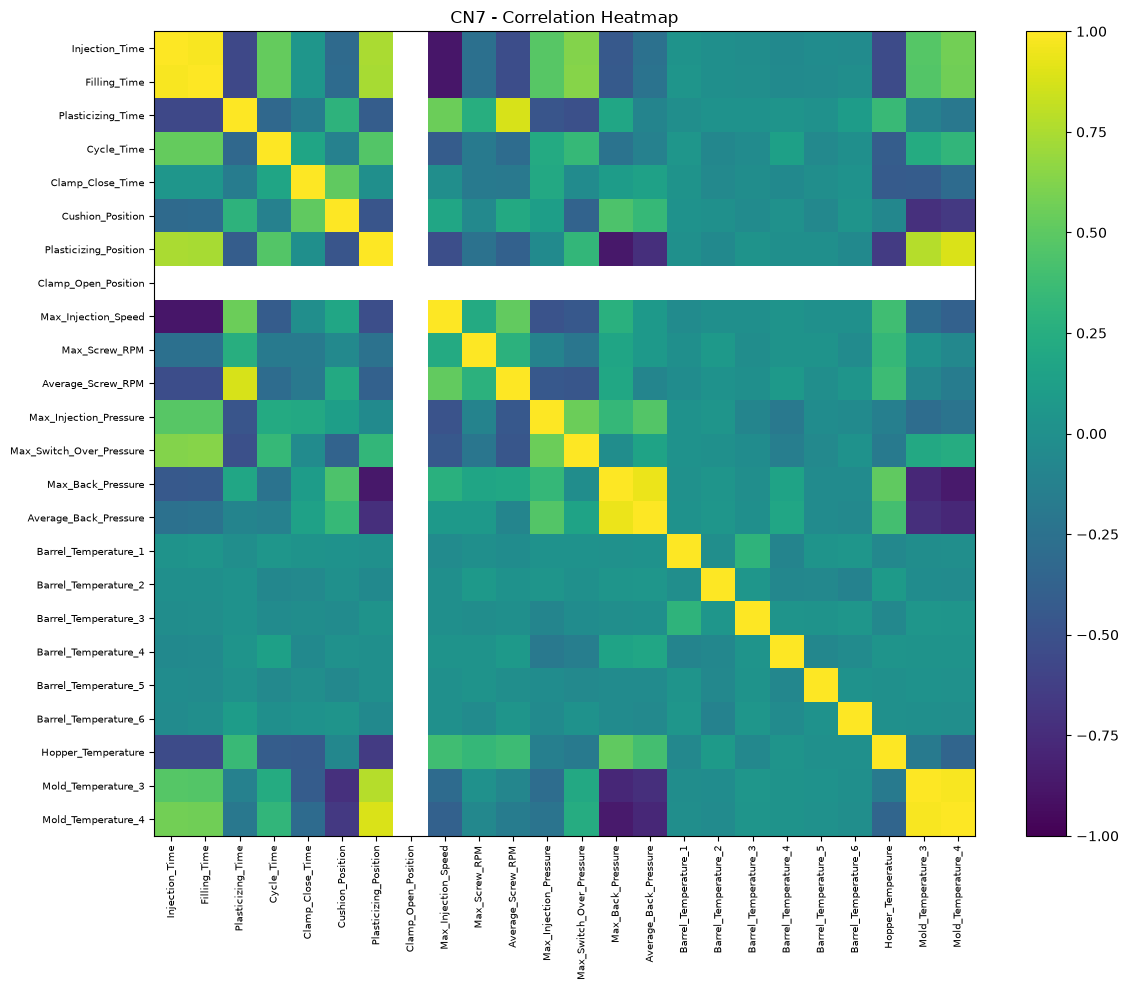

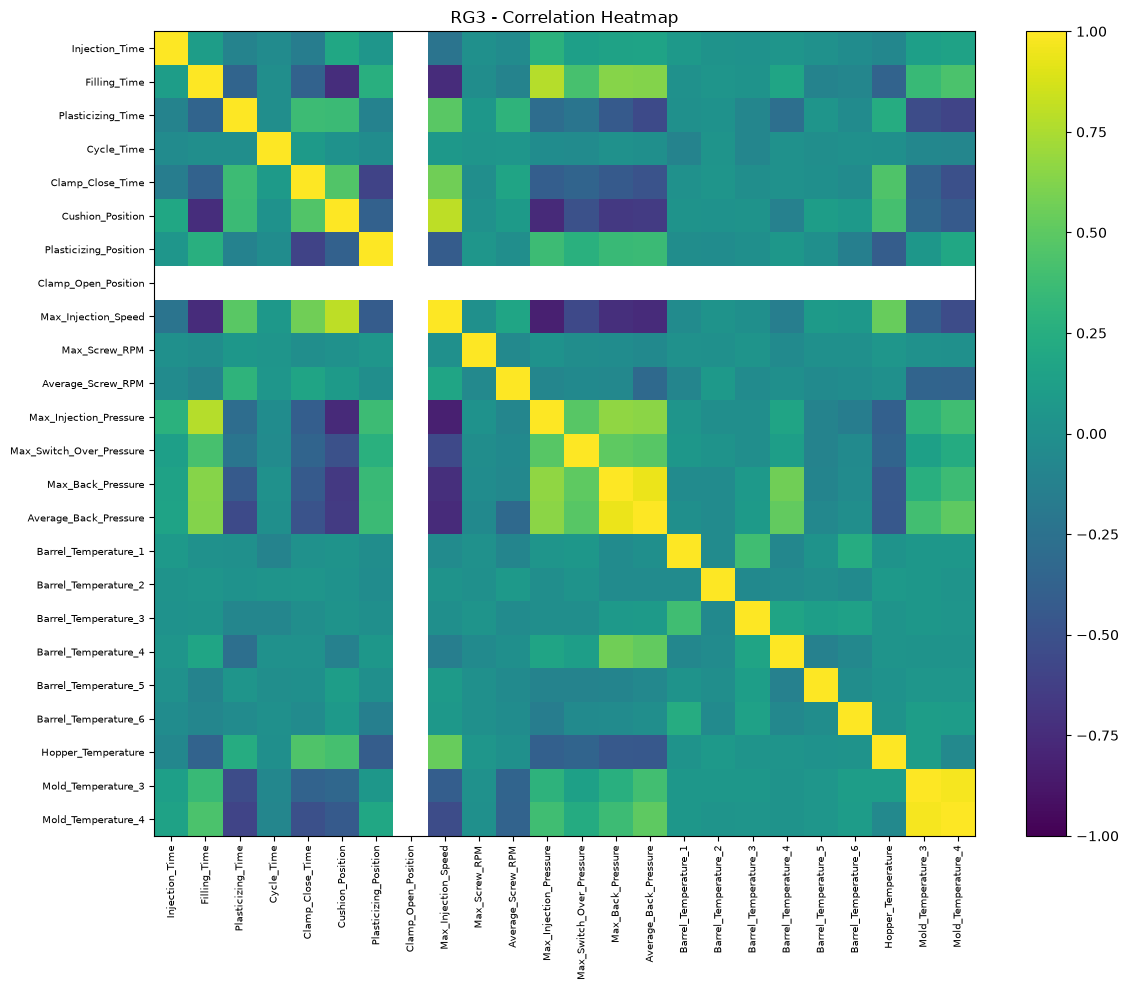

In [87]:
# Correlation Heatmap
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr, aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
    ax.set_title(f"{name} - Correlation Heatmap")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


### 3) 강한 양의 상관관계 확인

- 변수 간 선형 관계와 중복 정보 가능성을 확인합니다.


In [88]:
# 강한 양의 상관관계(0.8 이상) 변수쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}] 강한 양의 상관")
    display(pairs[pairs >= 0.8].to_frame("corr"))



[CN7] 강한 양의 상관


,,corr
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053
Max_Back_Pressure,Average_Back_Pressure,0.940203
Plasticizing_Position,Mold_Temperature_4,0.888511
Plasticizing_Time,Average_Screw_RPM,0.876645



[RG3] 강한 양의 상관


,,corr
Mold_Temperature_3,Mold_Temperature_4,0.973648
Max_Back_Pressure,Average_Back_Pressure,0.941280
Cushion_Position,Max_Injection_Speed,0.800543


### 4) 강한 음의 상관관계 확인

- 변수 간 선형 관계와 중복 정보 가능성을 확인합니다.


In [89]:
# 강한 음의 상관관계(-0.8 이하) 변수쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values()

    print(f"\n[{name}] 강한 음의 상관")
    display(pairs[pairs <= -0.8].to_frame("corr"))



[CN7] 강한 음의 상관


,,corr
Filling_Time,Max_Injection_Speed,-0.877361
Injection_Time,Max_Injection_Speed,-0.875086
Plasticizing_Position,Max_Back_Pressure,-0.871511
Max_Back_Pressure,Mold_Temperature_4,-0.854748



[RG3] 강한 음의 상관


,,corr
Max_Injection_Speed,Max_Injection_Pressure,-0.823768


### 5) 서로 거의 동일하게 움직이는 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [90]:
# 거의 동일하게 움직이는 변수(|corr| >= 0.95) 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    near_same = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(near_same[near_same >= 0.95].to_frame("|corr|"))



[CN7]


,,|corr|
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053



[RG3]


,,|corr|
Mold_Temperature_3,Mold_Temperature_4,0.973648


### 6) 중복 정보를 가지는 변수 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [91]:
# 중복 정보 가능성이 높은 변수쌍(|corr| >= 0.90) 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(redundant[redundant >= 0.90].to_frame("|corr|"))



[CN7]


,,|corr|
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053
Max_Back_Pressure,Average_Back_Pressure,0.940203



[RG3]


,,|corr|
Mold_Temperature_3,Mold_Temperature_4,0.973648
Max_Back_Pressure,Average_Back_Pressure,0.941280


### 7) 다중공선성 후보 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [95]:
# 다중공선성 후보: 다른 변수와 |corr| >= 0.90인 변수가 몇 개인지 확인
for name, df in DATASETS.items():

    corr = df[FEATURE_COLS].corr().abs()

    # 자기 자신과의 상관계수 제외
    corr = corr.mask(
        np.eye(len(corr), dtype=bool),
        0
    )

    count = (
        (corr >= 0.90)
        .sum()
        .sort_values(ascending=False)
    )

    print(f"\n[{name}]")
    display(
        count[count > 0]
        .to_frame("high_corr_pair_count")
    )


[CN7]


,high_corr_pair_count
Injection_Time,1
Filling_Time,1
Max_Back_Pressure,1
Average_Back_Pressure,1
Mold_Temperature_3,1
Mold_Temperature_4,1



[RG3]


,high_corr_pair_count
Mold_Temperature_3,1
Mold_Temperature_4,1
Max_Back_Pressure,1
Average_Back_Pressure,1


### 8) Target과 상관관계가 높은 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [93]:
# Target과의 Pearson 상관계수 확인
# 이진 Target에서는 point-biserial correlation과 동일한 형태로 해석 가능
for name, df in DATASETS.items():
    corr_target = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
    corr_target = corr_target.sort_values(key=np.abs, ascending=False)

    print(f"\n[{name}]")
    display(corr_target.to_frame("corr_with_target"))



[CN7]


,corr_with_target
Max_Injection_Speed,0.325751
Plasticizing_Position,0.178564
Max_Back_Pressure,-0.176061
Mold_Temperature_4,0.163068
Average_Back_Pressure,-0.159996
Cushion_Position,-0.151526
Mold_Temperature_3,0.145175
Max_Injection_Pressure,-0.144281
Clamp_Close_Time,0.143171
Max_Switch_Over_Pressure,0.101019



[RG3]


,corr_with_target
Barrel_Temperature_5,0.065518
Clamp_Close_Time,0.026628
Plasticizing_Time,0.025424
Max_Screw_RPM,0.020574
Barrel_Temperature_3,-0.020182
Hopper_Temperature,-0.019699
Average_Screw_RPM,0.019427
Barrel_Temperature_1,-0.017318
Max_Switch_Over_Pressure,0.014837
Plasticizing_Position,-0.014592


---


# #11 변수 간 관계 분석

### 1) 수치형 × 수치형 관계 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [96]:
# 수치형 변수쌍 중 절대 상관관계가 가장 높은 조합 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    print(f"\n[{name}] 상위 관계")
    display(upper.stack().sort_values(ascending=False).head(20).to_frame("|corr|"))



[CN7] 상위 관계


,,|corr|
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053
Max_Back_Pressure,Average_Back_Pressure,0.940203
Plasticizing_Position,Mold_Temperature_4,0.888511
Filling_Time,Max_Injection_Speed,0.877361
Plasticizing_Time,Average_Screw_RPM,0.876645
Injection_Time,Max_Injection_Speed,0.875086
Plasticizing_Position,Max_Back_Pressure,0.871511
Max_Back_Pressure,Mold_Temperature_4,0.854748
Average_Back_Pressure,Mold_Temperature_4,0.779824



[RG3] 상위 관계


|corr|
Mold_Temperature_3     Mold_Temperature_4      0.973648
Max_Back_Pressure      Average_Back_Pressure   0.941280
Max_Injection_Speed    Max_Injection_Pressure  0.823768
Cushion_Position       Max_Injection_Speed     0.800543
Filling_Time           Max_Injection_Pressure  0.774770
Cushion_Position       Max_Injection_Pressure  0.763337
Max_Injection_Speed    Average_Back_Pressure   0.750476
Filling_Time           Max_Injection_Speed     0.749909
                       Cushion_Position        0.737085
Max_Injection_Speed    Max_Back_Pressure       0.732532
Max_Injection_Pressure Max_Back_Pressure       0.670658
Cushion_Position       Max_Back_Pressure       0.670254
Max_Injection_Pressure Average_Back_Pressure   0.656175
Cushion_Position       Average_Back_Pressure   0.655266
Filling_Time           Max_Back_Pressure       0.638622
                       Average_Back_Pressure   0.625256
Clamp_Close_Time       Plasticizing_Position   0.594698
Plasticizing_Time      Mold_Temperature_4      0.590594
Max_Back_Pressure      Barrel_Temperature_4    0.570256
Clamp_Close_Time       Max_Injection_Speed     0.563274

### 2) Scatter Plot

- 수치형 변수쌍의 관계를 시각적으로 확인합니다.


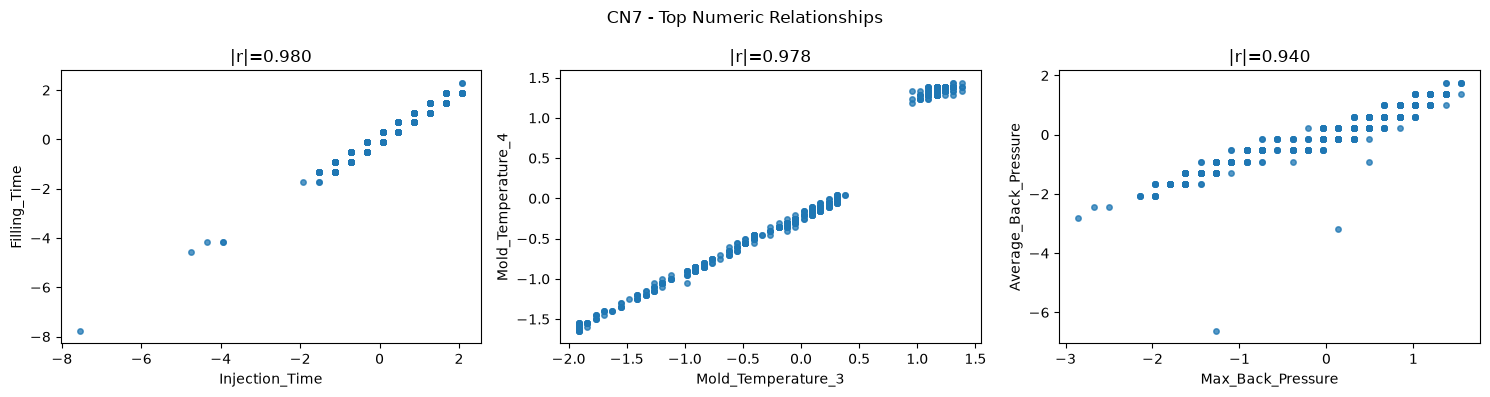

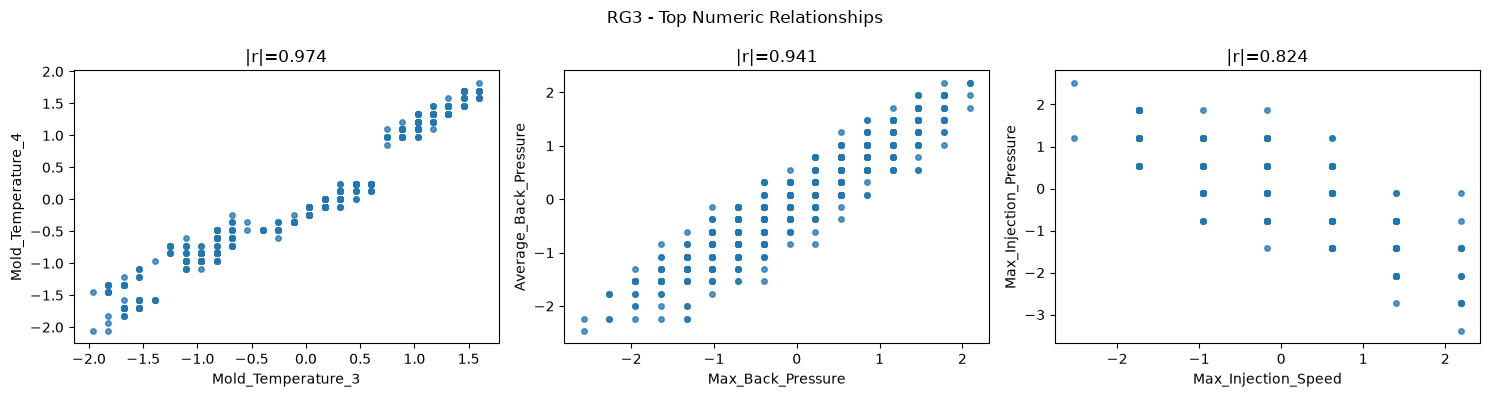

In [97]:
# 가장 강한 상관관계를 보이는 상위 3개 변수쌍 Scatter Plot
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top_pairs = upper.stack().sort_values(ascending=False).head(3).index.tolist()

    fig, axes = plt.subplots(1, len(top_pairs), figsize=(5 * max(1, len(top_pairs)), 4))
    axes = np.atleast_1d(axes)

    for ax, (x_col, y_col) in zip(axes, top_pairs):
        ax.scatter(df[x_col], df[y_col], alpha=0.5, s=15)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"|r|={abs(corr.loc[x_col, y_col]):.3f}")

    fig.suptitle(f"{name} - Top Numeric Relationships")
    plt.tight_layout()
    plt.show()


### 3) 범주형 × 수치형 관계 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [98]:
# 범주형 × 수치형 관계 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    num_cols = df[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()

    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없어 분석을 생략합니다.")
    else:
        for cat in cat_cols:
            display(df.groupby(cat)[num_cols].mean())


[CN7] 범주형 설명변수가 없어 분석을 생략합니다.
[RG3] 범주형 설명변수가 없어 분석을 생략합니다.


### 4) 범주별 평균 / 중앙값 비교

- 변수의 중심 수준을 비교합니다.


In [99]:
# 범주별 수치형 변수 평균 / 중앙값 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    num_cols = df[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()

    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없어 분석을 생략합니다.")
    else:
        for cat in cat_cols:
            display(df.groupby(cat)[num_cols].agg(["mean", "median"]))


[CN7] 범주형 설명변수가 없어 분석을 생략합니다.
[RG3] 범주형 설명변수가 없어 분석을 생략합니다.


### 5) 범주형 × 범주형 관계 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [100]:
# 범주형 변수끼리의 조합 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    if len(cat_cols) < 2:
        print(f"[{name}] 범주형 변수가 2개 미만이라 분석을 생략합니다.")
    else:
        for i in range(len(cat_cols) - 1):
            display(pd.crosstab(df[cat_cols[i]], df[cat_cols[i + 1]]))


[CN7] 범주형 변수가 2개 미만이라 분석을 생략합니다.
[RG3] 범주형 변수가 2개 미만이라 분석을 생략합니다.


### 6) 교차표 crosstab 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [101]:
# 범주형 변수 교차표 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    if len(cat_cols) < 2:
        print(f"[{name}] 범주형 변수가 2개 미만이라 crosstab 분석을 생략합니다.")
    else:
        display(pd.crosstab(df[cat_cols[0]], df[cat_cols[1]], normalize="index"))


[CN7] 범주형 변수가 2개 미만이라 crosstab 분석을 생략합니다.
[RG3] 범주형 변수가 2개 미만이라 crosstab 분석을 생략합니다.


### 7) 두 변수 조합에서 Target 차이가 발생하는지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [102]:
# 수치형 변수 2개를 각각 4분위 구간으로 나눈 뒤 조합별 Target 평균 확인
for name, df in DATASETS.items():
    corr_target = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
    top2 = corr_target.head(2).index.tolist()

    if len(top2) == 2:
        temp = df[[top2[0], top2[1], TARGET]].copy()
        temp[f"{top2[0]}_bin"] = pd.qcut(temp[top2[0]], q=4, duplicates="drop")
        temp[f"{top2[1]}_bin"] = pd.qcut(temp[top2[1]], q=4, duplicates="drop")

        result = temp.groupby(
            [f"{top2[0]}_bin", f"{top2[1]}_bin"],
            observed=True
        )[TARGET].agg(["count", "mean"])

        print(f"\n[{name}] {top2[0]} × {top2[1]}")
        display(result)



[CN7] Max_Injection_Speed × Plasticizing_Position


count      mean
Max_Injection_Speed_bin Plasticizing_Position_bin                     
(-1.543, -0.568]        (-0.642, 1.472]                  254  0.023622
                        (1.472, 1.592]                    93  0.021505
(-0.568, 0.0158]        (-2.8779999999999997, -0.703]    106  0.000000
                        (-0.703, -0.642]                  96  0.000000
                        (-0.642, 1.472]                   68  0.044118
                        (1.472, 1.592]                     2  0.000000
(0.0158, 0.405]         (-2.8779999999999997, -0.703]    188  0.000000
                        (-0.703, -0.642]                  98  0.000000
                        (-0.642, 1.472]                   88  0.000000
(0.405, 9.556]          (-2.8779999999999997, -0.703]    102  0.000000
                        (-0.703, -0.642]                  74  0.000000
                        (-0.642, 1.472]                   40  0.100000
                        (1.472, 1.592]                     2  1.000000


[RG3] Barrel_Temperature_5 × Clamp_Close_Time


count      mean
Barrel_Temperature_5_bin Clamp_Close_Time_bin                          
(-4.42, -0.658]          (-1.8079999999999998, -0.387]    200  0.005000
                         (-0.387, 1.033]                  152  0.013158
(-0.658, -0.0308]        (-1.8079999999999998, -0.387]    216  0.027778
                         (-0.387, 1.033]                  166  0.012048
(-0.0308, 0.596]         (-1.8079999999999998, -0.387]    146  0.013699
                         (-0.387, 1.033]                   96  0.041667
(0.596, 4.358]           (-1.8079999999999998, -0.387]    122  0.032787
                         (-0.387, 1.033]                   84  0.047619

---


# #12 이상치 분석

### 1) IQR 기준 이상치 확인

- 사분위 범위를 이용해 이상치 후보를 탐색합니다.


In [103]:
# IQR 기준 이상치 개수 및 비율 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    mask = (x < (q1 - 1.5 * iqr)) | (x > (q3 + 1.5 * iqr))
    result = pd.DataFrame({
        "outlier_count": mask.sum(),
        "outlier_ratio(%)": mask.mean() * 100
    }).sort_values("outlier_ratio(%)", ascending=False)

    print(f"\n[{name}]")
    display(result)



[CN7]


,outlier_count,outlier_ratio(%)
Average_Screw_RPM,308,25.433526
Barrel_Temperature_3,82,6.771263
Barrel_Temperature_5,44,3.633361
Cycle_Time,34,2.807597
Max_Injection_Pressure,28,2.312139
Barrel_Temperature_2,16,1.321222
Max_Injection_Speed,12,0.990917
Injection_Time,10,0.825764
Plasticizing_Time,10,0.825764
Filling_Time,10,0.825764



[RG3]


,outlier_count,outlier_ratio(%)
Barrel_Temperature_3,108,9.137056
Cycle_Time,66,5.583756
Barrel_Temperature_1,26,2.199662
Hopper_Temperature,24,2.030457
Barrel_Temperature_5,22,1.861252
Plasticizing_Time,22,1.861252
Injection_Time,16,1.353638
Max_Injection_Pressure,16,1.353638
Max_Switch_Over_Pressure,4,0.338409
Barrel_Temperature_2,4,0.338409


### 2) Z-score 기준 이상치 확인

- 평균에서 크게 벗어난 관측치를 확인합니다.


In [104]:
# Z-score 기준(|z| > 3) 이상치 개수 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    std = x.std(ddof=0).replace(0, np.nan)
    z = (x - x.mean()) / std

    result = pd.DataFrame({
        "|z|>3_count": (z.abs() > 3).sum(),
        "|z|>3_ratio(%)": (z.abs() > 3).mean() * 100
    }).sort_values("|z|>3_count", ascending=False)

    print(f"\n[{name}]")
    display(result)



[CN7]


,|z|>3_count,|z|>3_ratio(%)
Barrel_Temperature_5,16,1.321222
Injection_Time,10,0.825764
Max_Injection_Speed,10,0.825764
Filling_Time,10,0.825764
Max_Injection_Pressure,10,0.825764
Cushion_Position,8,0.660611
Cycle_Time,6,0.495458
Plasticizing_Time,6,0.495458
Average_Screw_RPM,6,0.495458
Max_Screw_RPM,6,0.495458



[RG3]


,|z|>3_count,|z|>3_ratio(%)
Injection_Time,16,1.353638
Barrel_Temperature_5,12,1.015228
Cycle_Time,8,0.676819
Plasticizing_Time,8,0.676819
Max_Switch_Over_Pressure,4,0.338409
Barrel_Temperature_2,4,0.338409
Max_Injection_Pressure,2,0.169205
Barrel_Temperature_1,2,0.169205
Hopper_Temperature,2,0.169205
Clamp_Open_Position,0,0.000000


### 3) Boxplot 확인

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientat

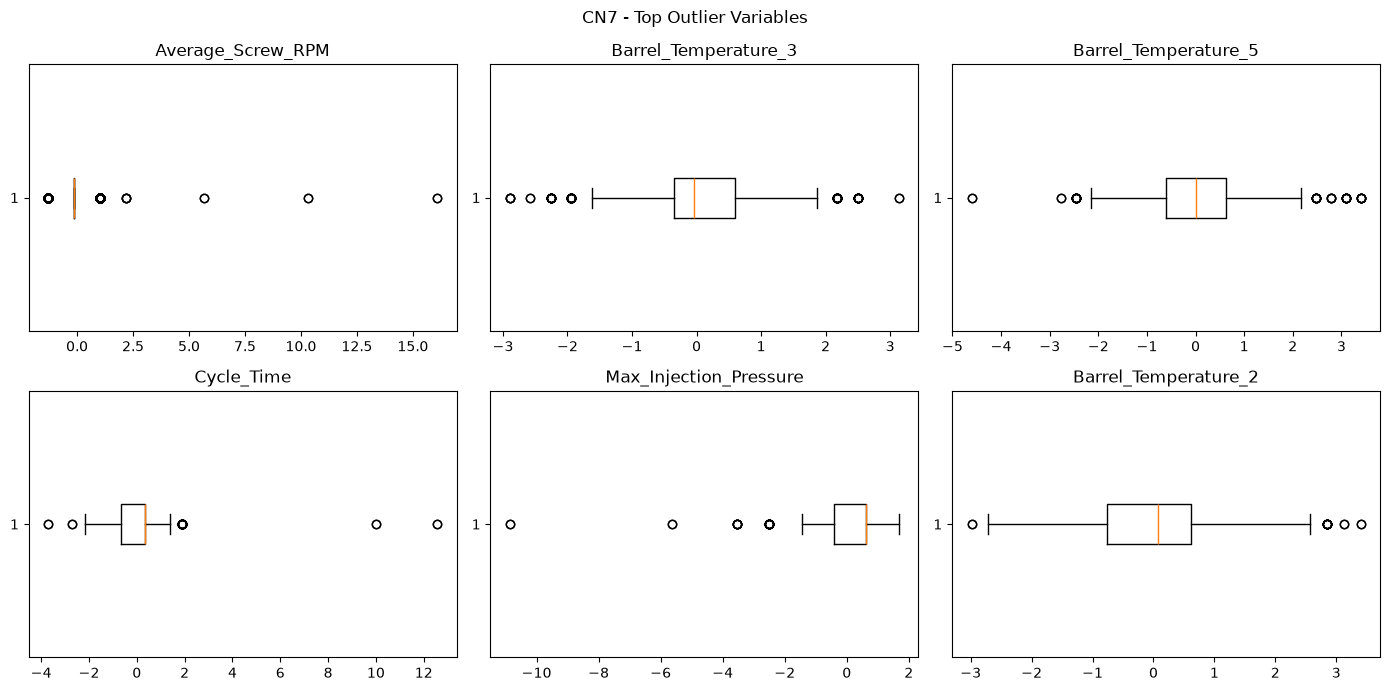

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14712\1457344852.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientat

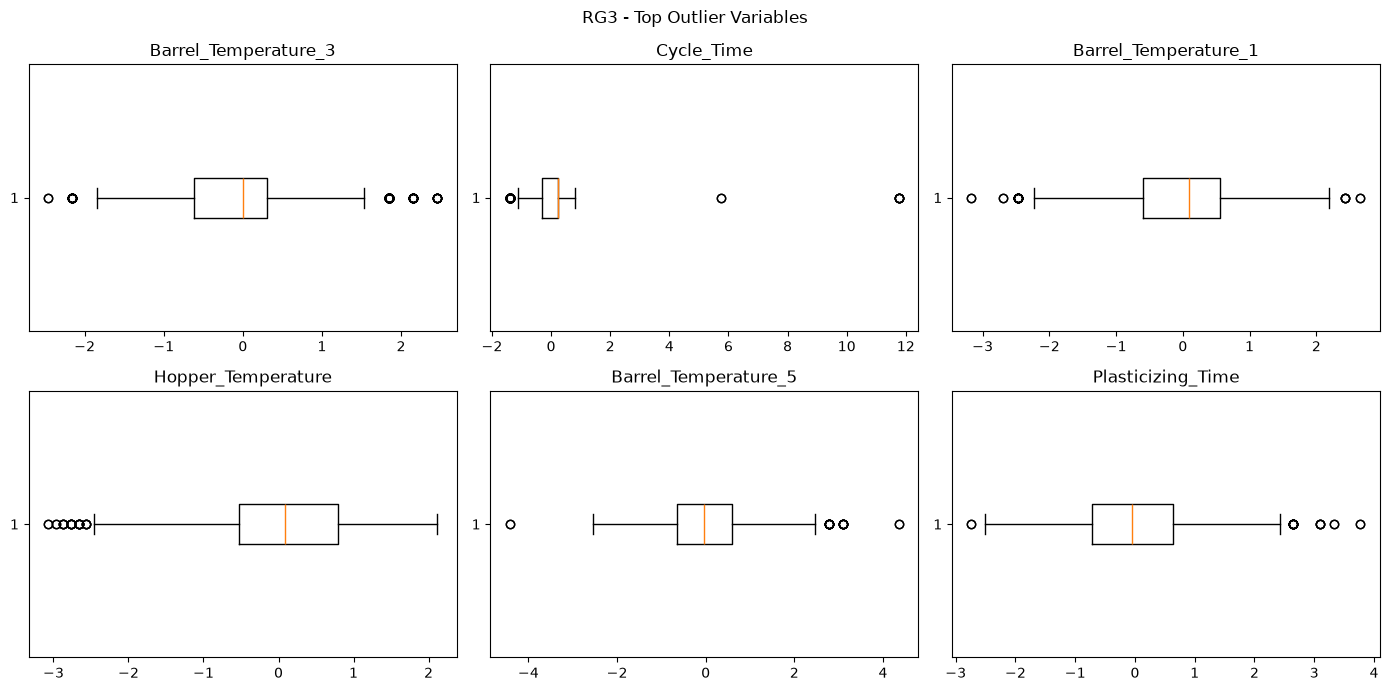

In [105]:
# IQR 이상치가 많은 상위 6개 변수 Boxplot
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    counts = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()
    top_cols = counts.sort_values(ascending=False).head(6).index

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.reshape(-1), top_cols):
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_title(col)

    fig.suptitle(f"{name} - Top Outlier Variables")
    plt.tight_layout()
    plt.show()


### 4) 상위 / 하위 극단값 직접 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [106]:
# 각 변수의 하위/상위 극단값 직접 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in FEATURE_COLS:
        low = df.nsmallest(3, col)[[col, TARGET]]
        high = df.nlargest(3, col)[[col, TARGET]]
        print(f"\n--- {col} ---")
        display(pd.concat({"LOW": low, "HIGH": high}))



[CN7]

--- Injection_Time ---


Injection_Time  PassOrFail
LOW  1209       -7.549091           0
     1210       -7.549091           0
     1207       -4.740484           0
HIGH 1           2.080358           1
     18          2.080358           0
     19          2.080358           0


--- Filling_Time ---


Filling_Time  PassOrFail
LOW  1209     -7.776799           0
     1210     -7.776799           0
     1207     -4.553063           0
HIGH 137       2.297327           0
     138       2.297327           0
     293       2.297327           0


--- Plasticizing_Time ---


...

Hopper_Temperature  PassOrFail
LOW  750           -3.070514           0
     751           -3.070514           0
     722           -2.968832           0
HIGH 314            2.115135           0
     315            2.115135           0
     88             2.013457           0


--- Mold_Temperature_3 ---


Mold_Temperature_3  PassOrFail
LOW  78             -1.963415           0
     79             -1.963415           0
     684            -1.963415           0
HIGH 1132            1.598652           1
     1133            1.598652           0
     1144            1.598652           0


--- Mold_Temperature_4 ---


Mold_Temperature_4  PassOrFail
LOW  78             -2.061609           0
     79             -2.061609           0
     80             -2.061609           0
HIGH 1132            1.822933           1
     1133            1.822933           0
     1100            1.701543           0

### 5) 특정 변수에서 이상치가 집중되는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [107]:
# 변수별 이상치 비율을 비교하여 특정 변수에 집중되는지 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    concentration = (mask.mean() * 100).sort_values(ascending=False)
    print(f"\n[{name}]")
    display(concentration.to_frame("outlier_ratio(%)"))



[CN7]


,outlier_ratio(%)
Average_Screw_RPM,25.433526
Barrel_Temperature_3,6.771263
Barrel_Temperature_5,3.633361
Cycle_Time,2.807597
Max_Injection_Pressure,2.312139
Barrel_Temperature_2,1.321222
Max_Injection_Speed,0.990917
Injection_Time,0.825764
Plasticizing_Time,0.825764
Filling_Time,0.825764



[RG3]


,outlier_ratio(%)
Barrel_Temperature_3,9.137056
Cycle_Time,5.583756
Barrel_Temperature_1,2.199662
Hopper_Temperature,2.030457
Barrel_Temperature_5,1.861252
Plasticizing_Time,1.861252
Injection_Time,1.353638
Max_Injection_Pressure,1.353638
Max_Switch_Over_Pressure,0.338409
Barrel_Temperature_2,0.338409


### 6) 특정 그룹에서만 이상치가 발생하는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [108]:
# 실제 그룹/설비/LOT 컬럼이 있는 경우 그룹별 이상치 비율을 비교
group_candidates = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "mold_id", "equipment", "group"])
]

if not group_candidates:
    print("현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹별 이상치 분석을 생략합니다.")
else:
    print("그룹 후보:", group_candidates)


현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹별 이상치 분석을 생략합니다.


### 7) Target과 이상치의 관계 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [109]:
# 행별 IQR 이상치 보유 여부와 Target 발생률의 관계 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    temp = df[[TARGET]].copy()
    temp["has_outlier"] = mask.any(axis=1)

    print(f"\n[{name}]")
    display(temp.groupby("has_outlier")[TARGET].agg(["count", "mean"]))



[CN7]


,count,mean
has_outlier,,
False,761,0.007884
True,450,0.024444



[RG3]


,count,mean
has_outlier,,
False,912,0.025219
True,270,0.007407


### 8) 실제 이상 데이터인지 정상적인 극단값인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [110]:
# 이상치 행을 Target과 함께 직접 확인
# 불량 데이터에 집중되는 극단값이면 공정 이상 신호일 수 있으므로 무조건 제거하지 않음
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    temp = df.copy()
    temp["outlier_feature_count"] = mask.sum(axis=1)

    print(f"\n[{name}] 이상치 변수가 많은 행")
    display(temp.sort_values("outlier_feature_count", ascending=False).head(20))



[CN7] 이상치 변수가 많은 행


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,outlier_feature_count
1210,1210,0,-7.549091,-7.776799,20.038456,-3.706092,-0.902466,6.943503,-2.876962,0.0,...,0.056153,-0.765355,0.914107,1.651976,-0.299626,2.290016,1.442471,0.093154,-0.205391,11
1209,1209,0,-7.549091,-7.776799,20.038456,-3.706092,-0.902466,6.943503,-2.876962,0.0,...,0.056153,-0.765355,0.914107,1.651976,-0.299626,2.290016,1.442471,0.093154,-0.205391,11
1207,1207,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,...,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391,8
1208,1208,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,...,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391,8
12,116,1,-3.938052,-4.150108,-0.281692,1.886261,0.978580,-2.613163,1.471608,0.0,...,-1.962742,0.067358,0.279582,-0.771388,0.008133,0.468557,-0.068281,1.166162,1.387105,5
13,117,1,-3.938052,-4.150108,-0.428933,-2.180975,0.978580,-2.613163,1.471608,0.0,...,1.177731,-1.042954,-0.355039,-0.006117,-0.299626,-0.897571,-1.075448,1.237697,1.387105,5
14,118,1,-3.938052,-4.150108,-0.428933,-2.180975,0.978580,-2.613163,1.471608,0.0,...,1.177731,-1.042954,-0.355039,-0.006117,-0.299626,-0.897571,-1.075448,1.237697,1.387105,5
11,115,1,-3.938052,-4.150108,-0.281692,1.886261,0.978580,-2.613163,1.471608,0.0,...,-1.962742,0.067358,0.279582,-0.771388,0.008133,0.468557,-0.068281,1.166162,1.387105,5
15,119,1,-4.339287,-4.150108,-0.478017,-1.672571,0.978580,-2.613163,1.592429,0.0,...,-0.392505,-0.210156,-0.672350,0.886706,-0.915098,-0.897571,-1.075448,1.237697,1.337339,5
16,120,1,-4.339287,-4.150108,-0.478017,-1.672571,0.978580,-2.613163,1.592429,0.0,...,-0.392505,-0.210156,-0.672350,0.886706,-0.915098,-0.897571,-1.075448,1.237697,1.337339,5



[RG3] 이상치 변수가 많은 행


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,outlier_feature_count
1156,2367,0,-0.029099,0.838552,-1.613854,11.761888,-0.386790,-1.114437,1.369662,0.0,...,-2.467412,0.715557,-2.153281,1.217754,0.909617,-1.348485,-0.426850,1.598652,1.701543,3
1157,2368,0,-0.029099,0.838552,-1.613854,11.761888,-0.386790,-1.114437,1.369662,0.0,...,-2.467412,0.715557,-2.153281,1.217754,0.909617,-1.348485,-0.426850,1.598652,1.701543,3
1073,2284,0,-0.029099,-1.192531,-0.267018,-1.395040,-0.386790,0.480326,0.588367,0.0,...,0.329736,-1.223184,-0.002081,-1.414723,3.103971,0.640193,-0.223487,1.171203,1.458758,2
70,1281,0,-8.627730,-1.192531,2.202217,-0.298708,1.033078,-1.114437,1.369662,0.0,...,0.562844,-0.980897,-0.002081,0.632729,-0.030765,-0.851297,0.183232,-1.535968,-1.697434,2
71,1282,0,-8.627730,-1.192531,2.202217,-0.298708,1.033078,-1.114437,1.369662,0.0,...,0.562844,-0.980897,-0.002081,0.632729,-0.030765,-0.851297,0.183232,-1.535968,-1.697434,2
1022,2233,0,8.569634,0.838552,-0.940436,0.249511,-0.386790,1.277707,0.588367,0.0,...,1.495203,0.715557,-0.002081,0.486518,-0.657751,1.137306,-1.341959,1.028719,1.215973,2
1023,2234,0,8.569634,0.838552,-0.940436,0.249511,-0.386790,1.277707,0.588367,0.0,...,1.495203,0.715557,-0.002081,0.486518,-0.657751,1.137306,-1.341959,1.028719,1.215973,2
48,1259,0,-0.029099,-1.192531,2.651155,-0.298708,1.033078,2.075089,0.588367,0.0,...,0.096629,1.442567,0.305246,-0.975955,0.282727,0.640193,-0.630206,-1.535968,-1.697434,2
314,1525,0,-0.029099,0.838552,1.079840,0.249511,1.033078,-0.317055,-0.192928,0.0,...,2.660669,0.957919,2.149119,-1.268467,-2.225119,0.143005,2.115135,-0.111141,-0.362122,2
315,1526,0,-0.029099,0.838552,1.079840,0.249511,1.033078,-0.317055,-0.192928,0.0,...,2.660669,0.957919,2.149119,-1.268467,-2.225119,0.143005,2.115135,-0.111141,-0.362122,2


---


# #13 ID / 그룹 구조 확인

### 1) ID별 데이터 개수

- 식별자 반복 구조를 확인합니다.


In [111]:
# ID 후보별 데이터 개수 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        display(df[col].value_counts().head(10).to_frame("row_count"))



[CN7]


,row_count
Unnamed: 0,
47,1
80,1
95,1
99,1
101,1
103,1
105,1
107,1
109,1



[RG3]


,row_count
Unnamed: 0,
1211,1
1212,1
1213,1
1214,1
1215,1
1216,1
1217,1
1218,1
1219,1


### 2) 그룹별 데이터 개수

- LOT/설비 등 그룹 구조가 있는지 확인합니다.


In [112]:
# LOT/설비/그룹 컬럼 후보 자동 탐색
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    print(f"[{name}] 그룹 컬럼 후보:", group_cols)

    for col in group_cols:
        display(df[col].value_counts().to_frame("count"))


[CN7] 그룹 컬럼 후보: []
[RG3] 그룹 컬럼 후보: []


### 3) 카테고리별 데이터 개수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [113]:
# 범주형 설명변수별 데이터 개수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(df[col].value_counts().to_frame("count"))


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 4) 그룹별 Target 비율

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [114]:
# 그룹 후보가 있다면 그룹별 Target 비율 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 그룹 컬럼이 없어 그룹별 Target 분석을 생략합니다.")
    for col in group_cols:
        display(df.groupby(col)[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False))


[CN7] 그룹 컬럼이 없어 그룹별 Target 분석을 생략합니다.
[RG3] 그룹 컬럼이 없어 그룹별 Target 분석을 생략합니다.


### 5) 특정 그룹에 데이터가 편중되어 있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [115]:
# 그룹별 표본 비중 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 그룹 컬럼이 없어 편중 분석을 생략합니다.")
    for col in group_cols:
        ratio = df[col].value_counts(normalize=True) * 100
        display(ratio.to_frame("ratio(%)"))


[CN7] 그룹 컬럼이 없어 편중 분석을 생략합니다.
[RG3] 그룹 컬럼이 없어 편중 분석을 생략합니다.


### 6) 한 ID가 여러 행을 가지는 구조인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [116]:
# 하나의 ID가 여러 행을 가지는지 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        counts = df[col].value_counts()
        print(col, "| 최대 반복 횟수:", counts.max(), "| 2회 이상 ID 수:", (counts >= 2).sum())



[CN7]
Unnamed: 0 | 최대 반복 횟수: 1 | 2회 이상 ID 수: 0

[RG3]
Unnamed: 0 | 최대 반복 횟수: 1 | 2회 이상 ID 수: 0


### 7) 동일 ID 데이터가 Train / Test에 섞일 가능성 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [117]:
# 현재 CN7/RG3에서 ID 값이 서로 겹치는지 참고 확인
# Unnamed: 0은 단순 행 번호 성격이므로 겹쳐도 동일 개체를 의미하지 않을 가능성이 큼
if ID_COLS:
    for col in ID_COLS:
        overlap = set(train_cn7[col]).intersection(set(train_rg3[col]))
        print(col, "| CN7-RG3 중복 값 수:", len(overlap))


Unnamed: 0 | CN7-RG3 중복 값 수: 0


In [118]:
# Train/Test 분리 시 단순 행 인덱스(Unnamed: 0)는 모델 Feature에서 제외
# 실제 제품 ID/LOT ID가 추가로 존재한다면 GroupShuffleSplit 등 그룹 기반 분할을 검토
print("모델링 시 제외할 ID 후보:", ID_COLS)


모델링 시 제외할 ID 후보: ['Unnamed: 0']


---


# #14 데이터 불균형 / 편향 확인

### 1) Target 불균형 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [119]:
# Target 클래스 불균형 재확인
for name, df in DATASETS.items():
    counts = df[TARGET].value_counts().sort_index()
    ratios = df[TARGET].value_counts(normalize=True).sort_index() * 100

    print(f"\n[{name}]")
    display(pd.DataFrame({"count": counts, "ratio(%)": ratios}))



[CN7]


,count,ratio(%)
PassOrFail,,
0,1194,98.596201
1,17,1.403799



[RG3]


,count,ratio(%)
PassOrFail,,
0,1157,97.884941
1,25,2.115059


### 2) 특정 그룹 편중 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [120]:
# 특정 그룹에 데이터가 몰려 있는지 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 명시적 그룹 컬럼이 없습니다.")
    for col in group_cols:
        display((df[col].value_counts(normalize=True) * 100).head(20).to_frame("ratio(%)"))


[CN7] 명시적 그룹 컬럼이 없습니다.
[RG3] 명시적 그룹 컬럼이 없습니다.


### 3) 특정 기간에 데이터 집중 여부 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [121]:
# 날짜형 컬럼이 있는 경우 특정 기간 집중 여부 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 기간 편향을 확인할 수 없습니다.")


[CN7] 날짜형 컬럼이 없어 기간 편향을 확인할 수 없습니다.
[RG3] 날짜형 컬럼이 없어 기간 편향을 확인할 수 없습니다.


### 4) 특정 카테고리 데이터 과다 여부 확인

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [122]:
# 특정 범주가 데이터 대부분을 차지하는지 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        top_ratio = df[col].value_counts(normalize=True).iloc[0] * 100
        print(col, "최다 범주 비율:", round(top_ratio, 2), "%")


[CN7] 범주형 설명변수가 없습니다.
[RG3] 범주형 설명변수가 없습니다.


### 5) 소수 그룹의 표본 수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [123]:
# 그룹/범주별 표본 수가 너무 적은 경우 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 소수 범주를 확인할 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        small = df[col].value_counts()
        display(small[small < 10].to_frame("count"))


[CN7] 소수 범주를 확인할 범주형 설명변수가 없습니다.
[RG3] 소수 범주를 확인할 범주형 설명변수가 없습니다.


### 6) Train / Test 분포 차이 가능성 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [124]:
# 현재 파일은 별도의 Train/Test 세트가 아니라 CN7/RG3 두 데이터셋이므로
# 참고용으로 동일 변수의 평균/표준편차 차이를 비교
compare = pd.DataFrame({
    "CN7_mean": train_cn7[FEATURE_COLS].mean(),
    "RG3_mean": train_rg3[FEATURE_COLS].mean(),
    "CN7_std": train_cn7[FEATURE_COLS].std(),
    "RG3_std": train_rg3[FEATURE_COLS].std(),
})
compare["mean_diff"] = compare["CN7_mean"] - compare["RG3_mean"]
display(compare.sort_values("mean_diff", key=np.abs, ascending=False))


,CN7_mean,RG3_mean,CN7_std,RG3_std,mean_diff
Cushion_Position,4.630532e-12,2.788886e-12,1.000413,1.000423,1.841646e-12
Plasticizing_Position,-3.628403e-14,1.813267e-13,1.000413,1.000423,-2.176107e-13
Max_Injection_Pressure,1.074909e-13,-7.252105e-14,1.000413,1.000423,1.800119e-13
Average_Screw_RPM,4.196368e-14,-8.432736e-14,1.000413,1.000423,1.262910e-13
Barrel_Temperature_5,5.257195e-15,-7.989698e-14,1.000413,1.000423,8.515418e-14
Barrel_Temperature_2,-3.505481e-14,4.473654e-14,1.000413,1.000423,-7.979135e-14
Clamp_Close_Time,-1.574811e-14,4.972597e-14,1.000413,1.000423,-6.547408e-14
Max_Injection_Speed,3.238808e-15,-2.755607e-14,1.000413,1.000423,3.079488e-14
Barrel_Temperature_1,-1.824176e-14,-4.462308e-14,1.000413,1.000423,2.638131e-14
Plasticizing_Time,6.477615e-15,-1.760126e-14,1.000413,1.000423,2.407888e-14


---


# #15 파생변수 후보 탐색

### 1) 변수 간 비율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [125]:
# 변수 간 비율 파생변수 후보
# 0으로 나누는 문제를 막기 위해 0을 NaN으로 치환
feature_preview = train_cn7.copy()
feature_preview["Injection_to_Filling_Ratio"] = (
    feature_preview["Injection_Time"] /
    feature_preview["Filling_Time"].replace(0, np.nan)
)
feature_preview[["Injection_Time", "Filling_Time", "Injection_to_Filling_Ratio"]].head()


,Injection_Time,Filling_Time,Injection_to_Filling_Ratio
0,1.277888,1.491397,0.856840
1,2.080358,1.894372,1.098179
2,1.679123,1.894372,0.886375
3,1.679123,1.491397,1.125872
4,1.277888,1.491397,0.856840


### 2) 변수 간 차이

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [126]:
# 변수 간 차이 파생변수 후보
feature_preview = train_cn7.copy()
feature_preview["Injection_minus_Filling"] = (
    feature_preview["Injection_Time"] - feature_preview["Filling_Time"]
)
feature_preview[["Injection_Time", "Filling_Time", "Injection_minus_Filling"]].head()


,Injection_Time,Filling_Time,Injection_minus_Filling
0,1.277888,1.491397,-0.213509
1,2.080358,1.894372,0.185987
2,1.679123,1.894372,-0.215248
3,1.679123,1.491397,0.187726
4,1.277888,1.491397,-0.213509


### 3) 합계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [127]:
# 주요 공정 시간 합계 파생변수 후보
feature_preview = train_cn7.copy()
time_cols = ["Injection_Time", "Filling_Time", "Plasticizing_Time", "Clamp_Close_Time"]
feature_preview["Process_Time_Sum"] = feature_preview[time_cols].sum(axis=1)
feature_preview[time_cols + ["Process_Time_Sum"]].head()


,Injection_Time,Filling_Time,Plasticizing_Time,Clamp_Close_Time,Process_Time_Sum
0,1.277888,1.491397,-0.625267,0.97858,3.122598
1,2.080358,1.894372,-0.478017,0.97858,4.475293
2,1.679123,1.894372,-0.330766,0.97858,4.221309
3,1.679123,1.491397,-0.428933,0.97858,3.720168
4,1.277888,1.491397,-0.428933,0.97858,3.318933


### 4) 평균

- 변수의 중심 수준을 비교합니다.


In [128]:
# RPM 관련 평균 파생변수 후보
feature_preview = train_cn7.copy()
feature_preview["Screw_RPM_Mean"] = feature_preview[
    ["Max_Screw_RPM", "Average_Screw_RPM"]
].mean(axis=1)
feature_preview[["Max_Screw_RPM", "Average_Screw_RPM", "Screw_RPM_Mean"]].head()


,Max_Screw_RPM,Average_Screw_RPM,Screw_RPM_Mean
0,-1.641030,-0.132022,-0.886526
1,0.049553,-0.132022,-0.041234
2,-0.795730,-0.132022,-0.463876
3,-1.641030,-0.132022,-0.886526
4,0.894853,-0.132022,0.381416


### 5) 최댓값 / 최솟값

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [129]:
# 배럴 온도의 행별 최댓값 / 최솟값 / 범위 파생변수 후보
feature_preview = train_cn7.copy()
barrel_cols = [c for c in FEATURE_COLS if c.startswith("Barrel_Temperature_")]

feature_preview["Barrel_Temp_Max"] = feature_preview[barrel_cols].max(axis=1)
feature_preview["Barrel_Temp_Min"] = feature_preview[barrel_cols].min(axis=1)
feature_preview["Barrel_Temp_Range"] = feature_preview["Barrel_Temp_Max"] - feature_preview["Barrel_Temp_Min"]

feature_preview[barrel_cols + ["Barrel_Temp_Max", "Barrel_Temp_Min", "Barrel_Temp_Range"]].head()


,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temp_Max,Barrel_Temp_Min,Barrel_Temp_Range
0,-0.168176,-0.210156,0.279582,1.269321,0.623605,0.923887,1.269321,-0.210156,1.479478
1,-0.392505,0.900156,-0.037728,-0.388733,1.546836,0.923887,1.546836,-0.392505,1.939341
2,-0.168176,2.843181,0.596893,-0.516285,-2.761513,1.834616,2.843181,-2.761513,5.604694
3,-1.065425,0.344957,-1.941496,0.631602,0.315892,-1.352970,0.631602,-1.941496,2.573098
4,1.177731,-1.320553,0.279582,1.141770,0.315892,-1.352970,1.177731,-1.352970,2.530702


### 6) 누적값

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [130]:
# 누적값은 시간 순서가 보장될 때 의미가 있음
# 현재는 명시적 타임스탬프가 없어 행 순서를 생산 순서로 단정하지 않음
print("명시적 시간/생산순서 컬럼이 없으므로 누적값 파생은 현재 단계에서 보류합니다.")


명시적 시간/생산순서 컬럼이 없으므로 누적값 파생은 현재 단계에서 보류합니다.


### 7) 횟수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [131]:
# 한 행에서 극단적인 센서값(|z| > 3)이 몇 개인지 개수 파생
feature_preview = train_cn7.copy()
x = feature_preview[FEATURE_COLS]
z = (x - x.mean()) / x.std(ddof=0).replace(0, np.nan)

feature_preview["Extreme_Feature_Count"] = (z.abs() > 3).sum(axis=1)
feature_preview[["Extreme_Feature_Count", TARGET]].head()


,Extreme_Feature_Count,PassOrFail
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### 8) 빈도

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [132]:
# 동일한 공정조건(X)이 반복된 빈도를 파생변수 후보로 확인
feature_preview = train_cn7.copy()

condition_freq = (
    feature_preview.groupby(FEATURE_COLS, dropna=False)[TARGET]
    .transform("size")
)
feature_preview["Condition_Frequency"] = condition_freq

feature_preview[["Condition_Frequency", TARGET]].head()


,Condition_Frequency,PassOrFail
0,2,1
1,2,1
2,2,1
3,2,1
4,2,1


### 9) 최근 N개 평균

- 변수의 중심 수준을 비교합니다.


In [133]:
# 최근 N개 평균은 행 순서가 생산 순서를 의미할 때만 사용
# 현재는 탐색용으로만 계산하며 모델 투입 전 데이터 정의를 반드시 확인
N = 5
rolling_preview = train_cn7[FEATURE_COLS].rolling(N, min_periods=1).mean()
rolling_preview.add_suffix(f"_rolling_mean_{N}").head()


,Injection_Time_rolling_mean_5,Filling_Time_rolling_mean_5,Plasticizing_Time_rolling_mean_5,Cycle_Time_rolling_mean_5,Clamp_Close_Time_rolling_mean_5,Cushion_Position_rolling_mean_5,Plasticizing_Position_rolling_mean_5,Clamp_Open_Position_rolling_mean_5,Max_Injection_Speed_rolling_mean_5,Max_Screw_RPM_rolling_mean_5,...,Average_Back_Pressure_rolling_mean_5,Barrel_Temperature_1_rolling_mean_5,Barrel_Temperature_2_rolling_mean_5,Barrel_Temperature_3_rolling_mean_5,Barrel_Temperature_4_rolling_mean_5,Barrel_Temperature_5_rolling_mean_5,Barrel_Temperature_6_rolling_mean_5,Hopper_Temperature_rolling_mean_5,Mold_Temperature_3_rolling_mean_5,Mold_Temperature_4_rolling_mean_5
0,1.277888,1.491397,-0.625267,0.361047,0.97858,-0.711164,1.471608,0.0,-1.152398,-1.641030,...,-0.152634,-0.168176,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574
1,1.679123,1.692884,-0.551642,0.361047,0.97858,-0.711164,1.471608,0.0,-1.249747,-0.795738,...,-0.343204,-0.280341,0.345000,0.120927,0.440294,1.085220,0.923887,-0.773295,1.237697,1.337339
2,1.679123,1.760047,-0.478017,0.361047,0.97858,-0.073275,1.471608,0.0,-1.282196,-0.795736,...,-0.533769,-0.242953,1.177727,0.279582,0.121435,-0.197024,1.227464,-0.370429,1.261541,1.353928
3,1.679123,1.692884,-0.465746,0.615250,0.97858,-0.232748,1.471608,0.0,-1.201074,-1.007059,...,-0.533770,-0.448571,0.969534,-0.275687,0.248977,-0.068795,0.582355,-0.471146,1.255580,1.362222
4,1.598876,1.652587,-0.458383,0.767771,0.97858,-0.328431,1.471608,0.0,-1.152401,-0.626677,...,-0.533771,-0.123310,0.511517,-0.164633,0.427535,0.008142,0.195290,-0.592006,1.266310,1.367199


### 10) 최근 N개 합계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [134]:
# 최근 N개 합계 역시 생산 순서가 확실한 경우에만 의미가 있음
N = 5
rolling_sum_preview = train_cn7[FEATURE_COLS].rolling(N, min_periods=1).sum()
rolling_sum_preview.add_suffix(f"_rolling_sum_{N}").head()


,Injection_Time_rolling_sum_5,Filling_Time_rolling_sum_5,Plasticizing_Time_rolling_sum_5,Cycle_Time_rolling_sum_5,Clamp_Close_Time_rolling_sum_5,Cushion_Position_rolling_sum_5,Plasticizing_Position_rolling_sum_5,Clamp_Open_Position_rolling_sum_5,Max_Injection_Speed_rolling_sum_5,Max_Screw_RPM_rolling_sum_5,...,Average_Back_Pressure_rolling_sum_5,Barrel_Temperature_1_rolling_sum_5,Barrel_Temperature_2_rolling_sum_5,Barrel_Temperature_3_rolling_sum_5,Barrel_Temperature_4_rolling_sum_5,Barrel_Temperature_5_rolling_sum_5,Barrel_Temperature_6_rolling_sum_5,Hopper_Temperature_rolling_sum_5,Mold_Temperature_3_rolling_sum_5,Mold_Temperature_4_rolling_sum_5
0,1.277888,1.491397,-0.625267,0.361047,0.978580,-0.711164,1.471608,0.0,-1.152398,-1.641030,...,-0.152634,-0.168176,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574
1,3.358246,3.385769,-1.103284,0.722095,1.957161,-1.422329,2.943216,0.0,-2.499493,-1.591477,...,-0.686408,-0.560681,0.690000,0.241854,0.880589,2.170440,1.847775,-1.546590,2.475393,2.674678
2,5.037369,5.280140,-1.434050,1.083142,2.935741,-0.219826,4.414824,0.0,-3.846588,-2.387207,...,-1.601306,-0.728858,3.533181,0.838747,0.364304,-0.591073,3.682391,-1.111287,3.784624,4.061783
3,6.716493,6.771538,-1.862983,2.460999,3.914321,-0.930991,5.886432,0.0,-4.804296,-4.028237,...,-2.135079,-1.794282,3.878138,-1.102748,0.995906,-0.275181,2.329421,-1.884582,5.022321,5.448888
4,7.994381,8.262935,-2.291916,3.838856,4.892902,-1.642155,7.358040,0.0,-5.762005,-3.133384,...,-2.668853,-0.616551,2.557585,-0.823166,2.137676,0.040712,0.976450,-2.960031,6.331551,6.835993


### 11) 변화량

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [135]:
# 직전 행 대비 변화량 확인
# 시간 순서가 확실하지 않으므로 현재는 EDA 후보로만 사용
diff_preview = train_cn7[FEATURE_COLS].diff()
diff_preview.add_suffix("_diff").head()


,Injection_Time_diff,Filling_Time_diff,Plasticizing_Time_diff,Cycle_Time_diff,Clamp_Close_Time_diff,Cushion_Position_diff,Plasticizing_Position_diff,Clamp_Open_Position_diff,Max_Injection_Speed_diff,Max_Screw_RPM_diff,...,Average_Back_Pressure_diff,Barrel_Temperature_1_diff,Barrel_Temperature_2_diff,Barrel_Temperature_3_diff,Barrel_Temperature_4_diff,Barrel_Temperature_5_diff,Barrel_Temperature_6_diff,Hopper_Temperature_diff,Mold_Temperature_3_diff,Mold_Temperature_4_diff
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.802470,0.402974,0.147251,0.000000,0.0,0.000000,0.0,0.0,-0.194697,1.690583,...,-0.381139,-0.224329,1.110312,-0.317311,-1.658054,0.923231,0.000000,-1.007168,0.143068,0.099531
2,-0.401235,0.000000,0.147251,0.000000,0.0,1.913667,0.0,0.0,0.000000,-0.845284,...,-0.381124,0.224329,1.943025,0.634621,-0.127552,-4.308349,0.910729,1.712182,0.000000,0.000000
3,0.000000,-0.402974,-0.098167,1.016809,0.0,-1.913667,0.0,0.0,0.389387,-0.845300,...,0.381124,-0.897249,-2.498224,-2.538389,1.147887,3.077406,-3.187587,-1.208598,-0.071534,0.000000
4,-0.401235,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,2.535883,...,0.000000,2.243156,-1.665511,2.221078,0.510168,0.000000,0.000000,-0.302153,0.071534,0.000000


### 12) 변화율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [136]:
# 직전 행 대비 변화율 확인
# 0으로 인한 inf는 NaN으로 치환
pct_preview = train_cn7[FEATURE_COLS].pct_change().replace([np.inf, -np.inf], np.nan)
pct_preview.add_suffix("_pct_change").head()


,Injection_Time_pct_change,Filling_Time_pct_change,Plasticizing_Time_pct_change,Cycle_Time_pct_change,Clamp_Close_Time_pct_change,Cushion_Position_pct_change,Plasticizing_Position_pct_change,Clamp_Open_Position_pct_change,Max_Injection_Speed_pct_change,Max_Screw_RPM_pct_change,...,Average_Back_Pressure_pct_change,Barrel_Temperature_1_pct_change,Barrel_Temperature_2_pct_change,Barrel_Temperature_3_pct_change,Barrel_Temperature_4_pct_change,Barrel_Temperature_5_pct_change,Barrel_Temperature_6_pct_change,Hopper_Temperature_pct_change,Mold_Temperature_3_pct_change,Mold_Temperature_4_pct_change
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.627966,0.270199,-0.235500,0.000000,0.0,0.000000,0.0,NaN,0.168950,-1.030196,...,2.497071,1.333895,-5.283269,-1.134945,-1.306253,1.480475,0.000000,3.734244,0.122683,0.077301
2,-0.192868,0.000000,-0.308045,0.000000,0.0,-2.690892,0.0,NaN,0.000000,-17.058107,...,0.714019,-0.571532,2.158543,-16.820870,0.328121,-2.785266,0.985758,-1.340912,0.000000,0.000000
3,0.000000,-0.212722,0.296788,2.816275,0.0,-1.591404,0.0,NaN,-0.289057,1.062294,...,-0.416576,5.335175,-0.878672,-4.252668,-2.223361,-1.114391,-1.737468,-2.776452,-0.054638,0.000000
4,-0.238955,0.000000,0.000000,0.000000,0.0,0.000000,0.0,NaN,0.000000,-1.545300,...,0.000000,-2.105410,-4.828163,-1.144004,0.807736,0.000000,0.000000,0.390735,0.057796,0.000000


### 13) 시간 간격

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [137]:
# 실제 타임스탬프가 있어야 생산 간 시간 간격을 계산할 수 있음
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
print("날짜형 컬럼:", date_cols)
print("현재는 시간 간격 파생변수를 만들 수 있는 타임스탬프가 없습니다." if not date_cols else "")


날짜형 컬럼: []
현재는 시간 간격 파생변수를 만들 수 있는 타임스탬프가 없습니다.


### 14) 최근 활동 이후 경과 시간

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [138]:
# 최근 활동 이후 경과 시간은 사용자 활동 로그 같은 시간 데이터에서 사용하는 변수
# 현재 사출 공정 데이터에는 해당 개념의 날짜 변수가 없음
print("최근 활동 이후 경과 시간 파생은 현재 데이터 구조에 적용하지 않습니다.")


최근 활동 이후 경과 시간 파생은 현재 데이터 구조에 적용하지 않습니다.


### 15) 그룹 내 평균 / 순위 / 편차

- 변수의 중심 수준을 비교합니다.


In [139]:
# 명시적 LOT/설비 그룹이 있다면 그룹 평균/편차/순위를 만들 수 있음
group_cols = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
]

if not group_cols:
    print("그룹 식별 컬럼이 없어 그룹 내 평균/순위/편차 파생은 보류합니다.")
else:
    print("사용 가능한 그룹 후보:", group_cols)


그룹 식별 컬럼이 없어 그룹 내 평균/순위/편차 파생은 보류합니다.


### 16) 여러 범주 조합

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [140]:
# 범주형 변수가 2개 이상이면 조합형 범주 파생 가능
cat_cols = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

if len(cat_cols) < 2:
    print("범주형 설명변수가 2개 미만이므로 범주 조합 파생은 적용하지 않습니다.")
else:
    temp = train_cn7.copy()
    temp["category_combo"] = temp[cat_cols[0]].astype(str) + "_" + temp[cat_cols[1]].astype(str)
    display(temp["category_combo"].value_counts().head())


범주형 설명변수가 2개 미만이므로 범주 조합 파생은 적용하지 않습니다.


### 17) 날짜 기반 연 / 월 / 요일 / 시간대 파생

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [141]:
# 날짜 기반 연/월/요일/시간대 파생
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

if not date_cols:
    print("날짜형 컬럼이 없어 날짜 기반 파생변수를 만들지 않습니다.")
else:
    temp = train_cn7.copy()
    col = date_cols[0]
    temp[f"{col}_year"] = temp[col].dt.year
    temp[f"{col}_month"] = temp[col].dt.month
    temp[f"{col}_weekday"] = temp[col].dt.dayofweek
    temp[f"{col}_hour"] = temp[col].dt.hour


날짜형 컬럼이 없어 날짜 기반 파생변수를 만들지 않습니다.


---


# #16 데이터 누수 가능성 확인

### 1) Target 결정 이후 생성되는 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [142]:
# 컬럼명 기준으로 Target 판정 이후 생성된 결과성 변수 후보 탐색
# 실제 공정 정의서가 있어야 최종 판단 가능
leakage_keywords = ["result", "label", "fail", "pass", "defect", "quality", "target"]
suspects = [
    c for c in FEATURE_COLS
    if any(k in c.lower() for k in leakage_keywords)
]
print("결과성 변수명 후보:", suspects)
print("※ 변수명만으로 누수를 확정할 수 없으며 공정 생성 시점을 확인해야 합니다.")


결과성 변수명 후보: []
※ 변수명만으로 누수를 확정할 수 없으며 공정 생성 시점을 확인해야 합니다.


### 2) Target 정보를 직접 포함하는 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [143]:
# Target과 완전히 동일하거나 반대인 수치형 컬럼이 있는지 확인
for name, df in DATASETS.items():
    direct_leak = []
    for col in FEATURE_COLS:
        if df[col].equals(df[TARGET]):
            direct_leak.append((col, "Target과 동일"))
        elif df[col].equals(1 - df[TARGET]):
            direct_leak.append((col, "Target과 반대"))
    print(f"[{name}] 직접 누수 후보:", direct_leak)


[CN7] 직접 누수 후보: []
[RG3] 직접 누수 후보: []


### 3) 결과값과 사실상 동일한 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [144]:
# Target과 상관계수 절대값이 0.999 이상인 변수 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).abs()
    print(f"[{name}] 사실상 동일 신호 후보:")
    display(corr[corr >= 0.999].sort_values(ascending=False).to_frame("|corr|"))


[CN7] 사실상 동일 신호 후보:


,|corr|


[RG3] 사실상 동일 신호 후보:


,|corr|


### 4) 미래 시점의 정보가 포함되어 있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [145]:
# 미래 정보 누수는 실제 타임스탬프와 예측 시점 정의가 있어야 판단 가능
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
print("날짜형 컬럼:", date_cols)
print("현재 데이터만으로는 미래 시점 정보 포함 여부를 시간 기준으로 검증할 수 없습니다.")


날짜형 컬럼: []
현재 데이터만으로는 미래 시점 정보 포함 여부를 시간 기준으로 검증할 수 없습니다.


### 5) Train 단계에서는 알 수 없는 정보인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [146]:
# 모델 예측 시점에 실제로 알 수 있는 공정 센서값인지 검토할 컬럼 목록
# 각 변수의 측정 시점(사출 전/중/후)을 공정 문서와 대조해야 함
review_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    "available_at_prediction_time": "공정 정의서 확인 필요"
})
display(review_table)


,feature,available_at_prediction_time
0,Injection_Time,공정 정의서 확인 필요
1,Filling_Time,공정 정의서 확인 필요
2,Plasticizing_Time,공정 정의서 확인 필요
3,Cycle_Time,공정 정의서 확인 필요
4,Clamp_Close_Time,공정 정의서 확인 필요
5,Cushion_Position,공정 정의서 확인 필요
6,Plasticizing_Position,공정 정의서 확인 필요
7,Clamp_Open_Position,공정 정의서 확인 필요
8,Max_Injection_Speed,공정 정의서 확인 필요
9,Max_Screw_RPM,공정 정의서 확인 필요


### 6) ID를 통해 Target을 간접적으로 알 수 있는지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [147]:
# ID가 Target을 지나치게 잘 구분하는지 확인
# ID별 Target 평균이 0 또는 1로 고정되는 것은 ID가 한 번만 등장하면 자연스러운 현상이므로 반복 ID 중심으로 판단
for name, df in DATASETS.items():
    for col in ID_COLS:
        g = df.groupby(col)[TARGET].agg(["count", "mean"])
        repeated = g[g["count"] >= 2]
        print(f"[{name}] {col} 반복 ID 수:", len(repeated))
        if len(repeated):
            display(repeated.head())


[CN7] Unnamed: 0 반복 ID 수: 0
[RG3] Unnamed: 0 반복 ID 수: 0


---


# #17 모델링 전 변수 점검

### 1) 사용하지 않을 ID성 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [148]:
# 모델 입력에서 제외할 ID성 컬럼 확인
drop_id_cols = ID_COLS.copy()
print("제거 후보:", drop_id_cols)


제거 후보: ['Unnamed: 0']


### 2) 상수 컬럼 제거 후보 확인

- 정보량이 없는 상수 또는 거의-상수 변수를 확인합니다.


In [149]:
# 상수 컬럼 제거 후보 확인
for name, df in DATASETS.items():
    constant_cols = [c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}] 상수 컬럼:", constant_cols)


[CN7] 상수 컬럼: ['Clamp_Open_Position']
[RG3] 상수 컬럼: ['Clamp_Open_Position']


### 3) 결측치 처리 필요 변수 확인

- 누락된 값의 개수와 비율을 확인합니다.


In [150]:
# 결측치 처리가 필요한 변수 확인
for name, df in DATASETS.items():
    missing = df[FEATURE_COLS].isna().sum()
    print(f"\n[{name}]")
    display(missing[missing > 0].sort_values(ascending=False).to_frame("missing_count"))



[CN7]


,missing_count



[RG3]


,missing_count


### 4) 범주형 인코딩 필요 변수 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [151]:
# 범주형 인코딩이 필요한 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"[{name}] 인코딩 필요 변수:", cat_cols)


[CN7] 인코딩 필요 변수: []
[RG3] 인코딩 필요 변수: []


### 5) 스케일링 필요 변수 확인

- 변수 간 값의 크기 차이를 확인합니다.


In [152]:
# 변수별 평균/표준편차를 확인해 스케일링 필요성 점검
# 이미 평균≈0, 표준편차≈1이라면 사전 표준화된 데이터일 가능성이 높음
for name, df in DATASETS.items():
    scale_check = pd.DataFrame({
        "mean": df[FEATURE_COLS].mean(),
        "std": df[FEATURE_COLS].std()
    })
    print(f"\n[{name}]")
    display(scale_check)



[CN7]


,mean,std
Injection_Time,-2.957172e-14,1.000413
Filling_Time,-5.351073e-15,1.000413
Plasticizing_Time,6.477615e-15,1.000413
Cycle_Time,5.069438e-14,1.000413
Clamp_Close_Time,-1.574811e-14,1.000413
Cushion_Position,4.630532e-12,1.000413
Plasticizing_Position,-3.628403e-14,1.000413
Clamp_Open_Position,0.000000e+00,0.000000
Max_Injection_Speed,3.238808e-15,1.000413
Max_Screw_RPM,-6.688842e-15,1.000413



[RG3]


,mean,std
Injection_Time,-4.715311e-14,1.000423
Filling_Time,-1.923635e-16,1.000423
Plasticizing_Time,-1.760126e-14,1.000423
Cycle_Time,5.502649e-14,1.000423
Clamp_Close_Time,4.972597e-14,1.000423
Cushion_Position,2.788886e-12,1.000423
Plasticizing_Position,1.813267e-13,1.000423
Clamp_Open_Position,0.000000e+00,0.000000
Max_Injection_Speed,-2.755607e-14,1.000423
Max_Screw_RPM,-1.206931e-14,1.000423


### 6) 로그 변환 후보 확인

- 강하게 치우친 양수 변수의 변환 필요성을 점검합니다.


In [153]:
# 양수이면서 왜도가 큰 변수만 로그 변환 후보로 분류
for name, df in DATASETS.items():
    candidates = [
        c for c in FEATURE_COLS
        if (df[c].dropna() > 0).all() and abs(df[c].skew()) > 1
    ]
    print(f"[{name}] 로그 변환 후보:", candidates)


[CN7] 로그 변환 후보: []
[RG3] 로그 변환 후보: []


### 7) 다중공선성 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [154]:
# |corr| >= 0.90인 다중공선성 후보쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(pairs[pairs >= 0.90].to_frame("|corr|"))



[CN7]


,,|corr|
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053
Max_Back_Pressure,Average_Back_Pressure,0.940203



[RG3]


,,|corr|
Mold_Temperature_3,Mold_Temperature_4,0.973648
Max_Back_Pressure,Average_Back_Pressure,0.941280


### 8) 파생변수 후보 정리

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [155]:
# 현재 데이터에서 우선 검토할 파생변수 후보 정리
derived_feature_candidates = [
    "Injection_Time / Filling_Time",
    "Injection_Time - Filling_Time",
    "주요 공정시간 합계",
    "Max_Screw_RPM과 Average_Screw_RPM 간 차이/비율",
    "배럴 온도 평균/최대/최소/범위",
    "Max_Back_Pressure와 Average_Back_Pressure 간 차이/비율",
    "행별 극단 센서값 개수",
    "동일 공정조건 반복 빈도"
]

pd.DataFrame({"파생변수 후보": derived_feature_candidates})


,파생변수 후보
0,Injection_Time / Filling_Time
1,Injection_Time - Filling_Time
2,주요 공정시간 합계
3,Max_Screw_RPM과 Average_Screw_RPM 간 차이/비율
4,배럴 온도 평균/최대/최소/범위
5,Max_Back_Pressure와 Average_Back_Pressure 간 차이/비율
6,행별 극단 센서값 개수
7,동일 공정조건 반복 빈도


### 9) Feature / Target 최종 구분

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [156]:
# 최종 Feature(X) / Target(y) 구분
X_cn7 = train_cn7.drop(columns=[TARGET] + ID_COLS)
y_cn7 = train_cn7[TARGET]

X_rg3 = train_rg3.drop(columns=[TARGET] + ID_COLS)
y_rg3 = train_rg3[TARGET]

print("CN7 X:", X_cn7.shape, "| y:", y_cn7.shape)
print("RG3 X:", X_rg3.shape, "| y:", y_rg3.shape)


CN7 X: (1211, 24) | y: (1211,)
RG3 X: (1182, 24) | y: (1182,)


---


# #18 EDA 최종 인사이트 정리

### 1) Target 분포 특징

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [157]:
# Target 분포 특징 요약
target_summary = []

for name, df in DATASETS.items():
    counts = df[TARGET].value_counts()
    target_summary.append({
        "dataset": name,
        "rows": len(df),
        "class_0": counts.get(0, 0),
        "class_1": counts.get(1, 0),
        "class_1_ratio(%)": counts.get(1, 0) / len(df) * 100,
        "imbalance_ratio": counts.max() / counts.min()
    })

pd.DataFrame(target_summary)


,dataset,rows,class_0,class_1,class_1_ratio(%),imbalance_ratio
0,CN7,1211,1194,17,1.403799,70.235294
1,RG3,1182,1157,25,2.115059,46.280000


### 2) 데이터 품질 문제

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [158]:
# 데이터 품질 문제 요약
quality_summary = []

for name, df in DATASETS.items():
    quality_summary.append({
        "dataset": name,
        "missing_total": int(df.isna().sum().sum()),
        "full_duplicate_rows": int(df.duplicated().sum()),
        "feature_duplicate_rows": int(df.duplicated(subset=FEATURE_COLS).sum()),
        "constant_cols": len([c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]),
        "inf_total": int(np.isinf(df.select_dtypes(include=np.number)).sum().sum())
    })

pd.DataFrame(quality_summary)


,dataset,missing_total,full_duplicate_rows,feature_duplicate_rows,constant_cols,inf_total
0,CN7,0,0,605,1,0
1,RG3,0,0,591,1,0


### 3) 주요 결측 변수

- 누락된 값의 개수와 비율을 확인합니다.


In [159]:
# 주요 결측 변수 요약
for name, df in DATASETS.items():
    missing = pd.DataFrame({
        "count": df[FEATURE_COLS].isna().sum(),
        "ratio(%)": df[FEATURE_COLS].isna().mean() * 100
    })
    print(f"\n[{name}]")
    display(missing[missing["count"] > 0].sort_values("count", ascending=False))



[CN7]


,count,ratio(%)



[RG3]


,count,ratio(%)


### 4) 주요 이상치 변수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [160]:
# 주요 이상치 변수 요약
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    result = pd.DataFrame({
        "outlier_count": mask.sum(),
        "outlier_ratio(%)": mask.mean() * 100
    }).sort_values("outlier_count", ascending=False)

    print(f"\n[{name}] TOP 10")
    display(result.head(10))



[CN7] TOP 10


,outlier_count,outlier_ratio(%)
Average_Screw_RPM,308,25.433526
Barrel_Temperature_3,82,6.771263
Barrel_Temperature_5,44,3.633361
Cycle_Time,34,2.807597
Max_Injection_Pressure,28,2.312139
Barrel_Temperature_2,16,1.321222
Max_Injection_Speed,12,0.990917
Injection_Time,10,0.825764
Plasticizing_Time,10,0.825764
Filling_Time,10,0.825764



[RG3] TOP 10


,outlier_count,outlier_ratio(%)
Barrel_Temperature_3,108,9.137056
Cycle_Time,66,5.583756
Barrel_Temperature_1,26,2.199662
Hopper_Temperature,24,2.030457
Barrel_Temperature_5,22,1.861252
Plasticizing_Time,22,1.861252
Injection_Time,16,1.353638
Max_Injection_Pressure,16,1.353638
Max_Switch_Over_Pressure,4,0.338409
Barrel_Temperature_2,4,0.338409


### 5) Target별 차이가 큰 변수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [161]:
# Target별 차이가 큰 변수 TOP 10
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].unique())
    if len(classes) == 2:
        c0, c1 = classes
        rows = []
        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col]
            x1 = df.loc[df[TARGET] == c1, col]
            pooled_std = np.sqrt((x0.var() + x1.var()) / 2)
            smd = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std
            rows.append([col, smd, abs(smd) if pd.notna(smd) else np.nan])

        result = pd.DataFrame(rows, columns=["feature", "SMD", "|SMD|"]).sort_values("|SMD|", ascending=False)
        print(f"\n[{name}]")
        display(result.head(10))



[CN7]


,feature,SMD,|SMD|
6,Plasticizing_Position,2.162762,2.162762
23,Mold_Temperature_4,1.970737,1.970737
22,Mold_Temperature_3,1.746339,1.746339
13,Max_Back_Pressure,-1.691928,1.691928
14,Average_Back_Pressure,-1.481356,1.481356
4,Clamp_Close_Time,1.465428,1.465428
5,Cushion_Position,-1.220081,1.220081
12,Max_Switch_Over_Pressure,0.929425,0.929425
21,Hopper_Temperature,-0.853325,0.853325
11,Max_Injection_Pressure,-0.823745,0.823745



[RG3]


,feature,SMD,|SMD|
19,Barrel_Temperature_5,0.474085,0.474085
4,Clamp_Close_Time,0.192717,0.192717
2,Plasticizing_Time,0.191062,0.191062
17,Barrel_Temperature_3,-0.159498,0.159498
9,Max_Screw_RPM,0.146513,0.146513
21,Hopper_Temperature,-0.141864,0.141864
10,Average_Screw_RPM,0.136215,0.136215
12,Max_Switch_Over_Pressure,0.123653,0.123653
15,Barrel_Temperature_1,-0.114499,0.114499
6,Plasticizing_Position,-0.107328,0.107328


### 6) Target과 관계가 강한 변수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [162]:
# Target과 상관관계가 강한 변수 TOP 10
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
    corr = corr.sort_values(key=np.abs, ascending=False)

    print(f"\n[{name}]")
    display(corr.head(10).to_frame("corr_with_target"))



[CN7]


,corr_with_target
Max_Injection_Speed,0.325751
Plasticizing_Position,0.178564
Max_Back_Pressure,-0.176061
Mold_Temperature_4,0.163068
Average_Back_Pressure,-0.159996
Cushion_Position,-0.151526
Mold_Temperature_3,0.145175
Max_Injection_Pressure,-0.144281
Clamp_Close_Time,0.143171
Max_Switch_Over_Pressure,0.101019



[RG3]


,corr_with_target
Barrel_Temperature_5,0.065518
Clamp_Close_Time,0.026628
Plasticizing_Time,0.025424
Max_Screw_RPM,0.020574
Barrel_Temperature_3,-0.020182
Hopper_Temperature,-0.019699
Average_Screw_RPM,0.019427
Barrel_Temperature_1,-0.017318
Max_Switch_Over_Pressure,0.014837
Plasticizing_Position,-0.014592


### 7) 변수 간 강한 관계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [163]:
# 변수 간 강한 관계 TOP 15
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    print(f"\n[{name}]")
    display(upper.stack().sort_values(ascending=False).head(15).to_frame("|corr|"))



[CN7]


,,|corr|
Injection_Time,Filling_Time,0.979820
Mold_Temperature_3,Mold_Temperature_4,0.978053
Max_Back_Pressure,Average_Back_Pressure,0.940203
Plasticizing_Position,Mold_Temperature_4,0.888511
Filling_Time,Max_Injection_Speed,0.877361
Plasticizing_Time,Average_Screw_RPM,0.876645
Injection_Time,Max_Injection_Speed,0.875086
Plasticizing_Position,Max_Back_Pressure,0.871511
Max_Back_Pressure,Mold_Temperature_4,0.854748
Average_Back_Pressure,Mold_Temperature_4,0.779824



[RG3]


|corr|
Mold_Temperature_3     Mold_Temperature_4      0.973648
Max_Back_Pressure      Average_Back_Pressure   0.941280
Max_Injection_Speed    Max_Injection_Pressure  0.823768
Cushion_Position       Max_Injection_Speed     0.800543
Filling_Time           Max_Injection_Pressure  0.774770
Cushion_Position       Max_Injection_Pressure  0.763337
Max_Injection_Speed    Average_Back_Pressure   0.750476
Filling_Time           Max_Injection_Speed     0.749909
                       Cushion_Position        0.737085
Max_Injection_Speed    Max_Back_Pressure       0.732532
Max_Injection_Pressure Max_Back_Pressure       0.670658
Cushion_Position       Max_Back_Pressure       0.670254
Max_Injection_Pressure Average_Back_Pressure   0.656175
Cushion_Position       Average_Back_Pressure   0.655266
Filling_Time           Max_Back_Pressure       0.638622

### 8) 특이한 그룹 패턴

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [164]:
# 그룹 패턴 분석 가능 여부 최종 확인
group_cols = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
]

if not group_cols:
    print("현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹 패턴 분석은 제한적입니다.")
else:
    print("그룹 후보:", group_cols)


현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹 패턴 분석은 제한적입니다.


### 9) 시간에 따른 변화 패턴

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [165]:
# 시간 패턴 분석 가능 여부 최종 확인
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

if not date_cols:
    print("현재 데이터에는 실제 날짜/타임스탬프 컬럼이 없어 시간에 따른 변화 패턴을 직접 분석할 수 없습니다.")
else:
    print("날짜형 컬럼:", date_cols)


현재 데이터에는 실제 날짜/타임스탬프 컬럼이 없어 시간에 따른 변화 패턴을 직접 분석할 수 없습니다.


### 10) 파생변수 후보

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [166]:
# 최종 파생변수 후보
final_derived_candidates = pd.DataFrame({
    "후보": [
        "Injection_to_Filling_Ratio",
        "Injection_minus_Filling",
        "Process_Time_Sum",
        "Max_vs_Average_Screw_RPM_Gap",
        "Barrel_Temp_Mean",
        "Barrel_Temp_Range",
        "Back_Pressure_Gap",
        "Extreme_Feature_Count",
        "Condition_Frequency"
    ],
    "목적": [
        "사출-충전 시간 균형",
        "사출-충전 시간 편차",
        "공정 시간 총량",
        "스크류 회전 안정성",
        "배럴 전체 온도 수준",
        "배럴 온도 균일성",
        "배압 안정성",
        "동시 이상 신호 개수",
        "동일 공정조건 반복성"
    ]
})
final_derived_candidates


,후보,목적
0,Injection_to_Filling_Ratio,사출-충전 시간 균형
1,Injection_minus_Filling,사출-충전 시간 편차
2,Process_Time_Sum,공정 시간 총량
3,Max_vs_Average_Screw_RPM_Gap,스크류 회전 안정성
4,Barrel_Temp_Mean,배럴 전체 온도 수준
5,Barrel_Temp_Range,배럴 온도 균일성
6,Back_Pressure_Gap,배압 안정성
7,Extreme_Feature_Count,동시 이상 신호 개수
8,Condition_Frequency,동일 공정조건 반복성


### 11) 제거 또는 전처리가 필요한 변수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [167]:
# 제거 또는 전처리 필요 변수 요약
preprocess_summary = []

for name, df in DATASETS.items():
    constant_cols = [c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]
    missing_cols = df[FEATURE_COLS].columns[df[FEATURE_COLS].isna().any()].tolist()
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    preprocess_summary.append({
        "dataset": name,
        "drop_id_cols": ID_COLS,
        "constant_cols": constant_cols,
        "missing_cols": missing_cols,
        "categorical_cols": cat_cols
    })

pd.DataFrame(preprocess_summary)


,dataset,drop_id_cols,constant_cols,missing_cols,categorical_cols
0,CN7,[Unnamed: 0],[Clamp_Open_Position],[],[]
1,RG3,[Unnamed: 0],[Clamp_Open_Position],[],[]


### 12) 모델링

- EDA 결과를 바탕으로 모델 입력 구조와 주의점을 정리합니다.


In [168]:
# 모델링 단계 준비
# Target 불균형이 매우 크므로 Accuracy만 보지 말고 Recall, Precision, F1, PR-AUC 등을 함께 확인
for name, df in DATASETS.items():
    X = df.drop(columns=[TARGET] + ID_COLS)
    y = df[TARGET]

    print(f"[{name}] X shape:", X.shape, "| y shape:", y.shape)
    print(f"[{name}] class distribution:")
    print(y.value_counts(normalize=True).sort_index())
    print()

print("모델링 시 권장:")
print("1) Stratified split 사용")
print("2) ID 컬럼 제외")
print("3) 클래스 불균형 대응(class_weight, sampling 등) 비교")
print("4) Accuracy 외 Recall / Precision / F1 / PR-AUC 확인")
print("5) CN7/RG3를 합칠 경우 제품군 차이를 반드시 검증")


[CN7] X shape: (1211, 24) | y shape: (1211,)
[CN7] class distribution:
PassOrFail
0    0.985962
1    0.014038
Name: proportion, dtype: float64

[RG3] X shape: (1182, 24) | y shape: (1182,)
[RG3] class distribution:
PassOrFail
0    0.978849
1    0.021151
Name: proportion, dtype: float64

모델링 시 권장:
1) Stratified split 사용
2) ID 컬럼 제외
3) 클래스 불균형 대응(class_weight, sampling 등) 비교
4) Accuracy 외 Recall / Precision / F1 / PR-AUC 확인
5) CN7/RG3를 합칠 경우 제품군 차이를 반드시 검증


---
